In [ ]:
!pip install astroquery -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astroquery.gaia import Gaia

print("✅ All libraries loaded successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

✅ All libraries loaded successfully!
NumPy: 2.0.2
Pandas: 2.2.2


In [ ]:
from astroquery.gaia import Gaia
import pandas as pd
import matplotlib.pyplot as plt
query = """
SELECT TOP 500
    source_id, ra, dec, parallax, parallax_error,
    pmra, pmdec, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE parallax BETWEEN 6 AND 8
AND pmra BETWEEN 18 AND 22
AND pmdec BETWEEN -48 AND -44
AND bp_rp IS NOT NULL
AND phot_g_mean_mag IS NOT NULL
"""

print("Querying Gaia satellite database...")
job = Gaia.launch_job(query)
df = job.get_results().to_pandas()

print(f"✅ Stars retrieved: {len(df)}")
print(df.head())

Querying Gaia satellite database...
✅ Stars retrieved: 500
             source_id          ra        dec  parallax  parallax_error  \
0   481448692670269312   86.004246  67.535084  6.986140        0.016784   
1  2173039910314775296  325.753274  51.891397  6.534315        0.037648   
2  2440129697209269632  351.970326  -7.501303  6.682363        0.017267   
3  2492232121570829056   31.473222  -4.045151  7.297028        0.103510   
4  2654311336779311104  340.398003   0.096412  6.514881        0.035020   

        pmra      pmdec  phot_g_mean_mag     bp_rp  
0  20.030496 -47.064437        11.827279  1.136086  
1  20.576846 -44.849170        16.108463  2.752267  
2  19.580682 -44.778552        11.623939  1.074317  
3  21.258225 -46.426054        17.156534  2.991539  
4  18.490862 -44.931242        15.369761  2.210470  


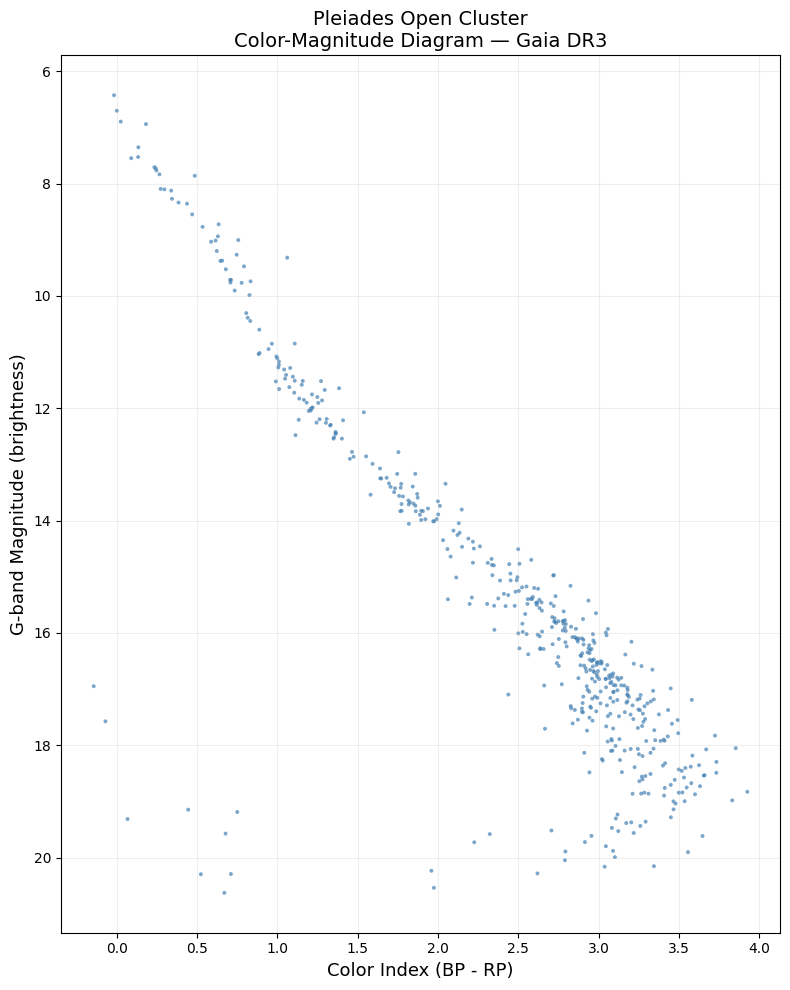

✅ Your first research plot saved as pleiades_cmd.png


In [ ]:
plt.figure(figsize=(8, 10))
plt.scatter(df['bp_rp'], df['phot_g_mean_mag'],
            s=8, alpha=0.7, color='steelblue', edgecolors='none')
plt.gca().invert_yaxis()
plt.xlabel('Color Index (BP - RP)', fontsize=13)
plt.ylabel('G-band Magnitude (brightness)', fontsize=13)
plt.title('Pleiades Open Cluster\nColor-Magnitude Diagram — Gaia DR3', fontsize=14)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('pleiades_cmd.png', dpi=150)
plt.show()

print("✅ Your first research plot saved as pleiades_cmd.png")

In [ ]:
!pip install astroquery astropy -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 48.0 MB/s eta 0:00:00


In [ ]:
from astroquery.gaia import Gaia
import pandas as pd
import numpy as np

query_praesepe = """
SELECT
    source_id,
    ra, dec,
    parallax, parallax_error,
    pmra, pmra_error,
    pmdec, pmdec_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    bp_rp,
    ruwe
FROM gaiadr3.gaia_source
WHERE CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', 130.05, 19.67, 3.0)
) = 1
AND parallax IS NOT NULL
AND phot_g_mean_mag IS NOT NULL
AND bp_rp IS NOT NULL
"""

job = Gaia.launch_job_async(query_praesepe)
results = job.get_results()
df_praesepe_raw = results.to_pandas()

print(f"Raw query returned: {len(df_praesepe_raw)} stars")
df_praesepe_raw.head()

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Raw query returned: 131567 stars


,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,ruwe
0,658069911227382784,129.508273,16.720638,0.131026,0.078468,-3.189237,0.076207,-1.066875,0.056225,17.045721,17.378391,16.487757,0.890635,0.957691
1,658070216169394688,129.509377,16.731267,0.008370,0.198902,2.205195,0.188653,-9.709030,0.138816,18.640409,18.974766,18.128448,0.846317,0.990711
2,658070456687571328,129.546341,16.751478,3.235400,1.560299,3.014719,1.487692,-2.059590,0.872192,20.778503,21.374949,19.465281,1.909668,1.001979
3,658081520523332352,129.410744,16.767789,1.636125,0.628263,0.659638,0.566514,-4.548908,0.391844,20.191231,21.411190,19.079638,2.331553,1.084764
4,658082070279145600,129.498934,16.767685,0.817726,0.871552,-3.213091,0.828517,-2.539791,0.584631,20.531479,20.828781,19.542988,1.285793,1.063097


In [ ]:

df_p = df_praesepe_raw.copy()

df_p = df_p[df_p['parallax_error'] / df_p['parallax'] < 0.1]
df_p = df_p[df_p['ruwe'] < 1.4]
df_p = df_p.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
print(f"After quality cuts: {len(df_p)} stars")

df_p = df_p[(df_p['parallax'] >= 4.5) & (df_p['parallax'] <= 6.5)]
print(f"After parallax cut: {len(df_p)} stars")


df_p = df_p[(df_p['pmra'] >= -38.7) & (df_p['pmra'] <= -32.7)]
df_p = df_p[(df_p['pmdec'] >= -15.9) & (df_p['pmdec'] <= -9.9)]
print(f"After proper motion cut: {len(df_p)} stars")

df_p.to_csv('praesepe_clean.csv', index=False)
print(f"\nSaved praesepe_clean.csv")
print(df_p[['parallax','pmra','pmdec','bp_rp','phot_g_mean_mag']].describe())

After quality cuts: 44800 stars
After parallax cut: 1849 stars
After proper motion cut: 921 stars

Saved praesepe_clean.csv
         parallax        pmra       pmdec       bp_rp  phot_g_mean_mag
count  921.000000  921.000000  921.000000  921.000000       921.000000
mean     5.402957  -35.908294  -12.865721    2.343226        15.679754
std      0.192152    1.176653    0.965753    0.942134         2.996629
min      4.551184  -38.627858  -15.830041   -0.318407         6.152467
25%      5.315474  -36.737875  -13.562882    1.690818        14.026043
50%      5.406968  -35.926731  -12.868031    2.740999        16.572800
75%      5.497834  -35.128084  -12.203135    3.074718        17.999487
max      6.431598  -32.734981  -10.239958    3.905756        20.099499


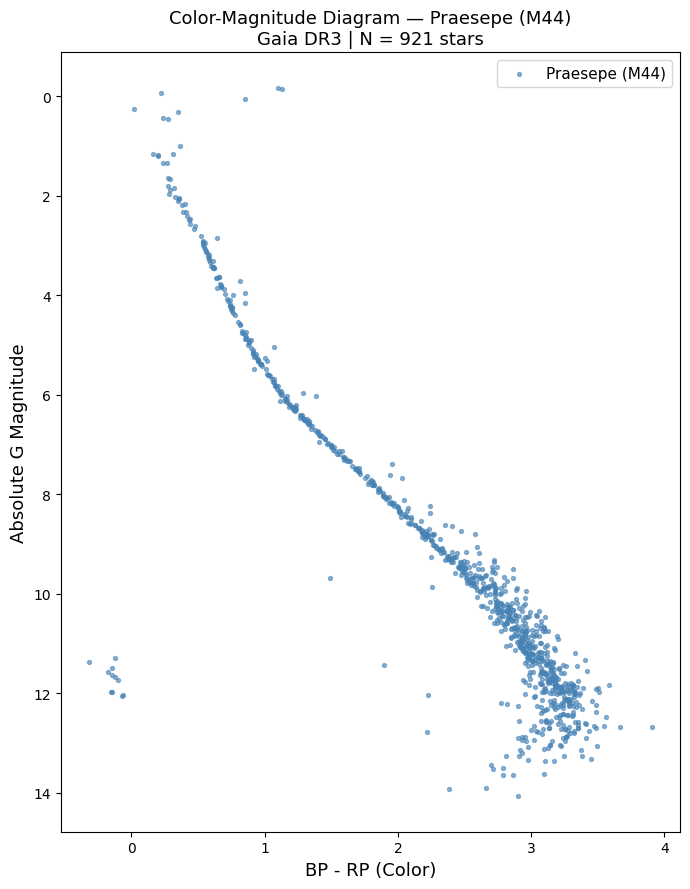

Saved cmd_praesepe.png


In [ ]:
import matplotlib.pyplot as plt

df_p['distance_pc'] = 1000 / df_p['parallax']
df_p['abs_mag'] = df_p['phot_g_mean_mag'] - 5 * np.log10(df_p['distance_pc']) + 5

fig, ax = plt.subplots(figsize=(7, 9))
ax.scatter(df_p['bp_rp'], df_p['abs_mag'],
           s=8, alpha=0.6, color='steelblue', label='Praesepe (M44)')

ax.set_xlabel('BP - RP (Color)', fontsize=13)
ax.set_ylabel('Absolute G Magnitude', fontsize=13)
ax.set_title('Color-Magnitude Diagram — Praesepe (M44)\nGaia DR3 | N = 921 stars', fontsize=13)
ax.invert_yaxis()
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('cmd_praesepe.png', dpi=150)
plt.show()

print("Saved cmd_praesepe.png")


In [ ]:
query_ngc2516 = """
SELECT
    source_id, ra, dec,
    parallax, parallax_error,
    pmra, pmra_error,
    pmdec, pmdec_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    bp_rp, ruwe
FROM gaiadr3.gaia_source
WHERE CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', 119.52, -60.75, 2.0)
) = 1
AND parallax IS NOT NULL
AND phot_g_mean_mag IS NOT NULL
AND bp_rp IS NOT NULL
"""

job = Gaia.launch_job_async(query_ngc2516)
results = job.get_results()
df_ngc2516_raw = results.to_pandas()

print(f"Raw query returned: {len(df_ngc2516_raw)} stars")
df_ngc2516_raw.head()

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Raw query returned: 313510 stars


,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,ruwe
0,5288070185603381248,119.120654,-62.740399,-0.006836,0.267760,-2.866324,0.353432,7.446991,0.312418,19.480312,20.222069,18.634819,1.587250,1.154441
1,5288070288682598528,119.188485,-62.720152,0.934004,0.100785,-6.716076,0.139365,10.662479,0.113718,18.214628,19.099375,17.325548,1.773827,0.965257
2,5288070323042906880,119.148382,-62.715927,-0.755590,1.033580,-6.975130,1.337576,7.236232,1.162439,20.675774,20.984150,19.731892,1.252258,1.088100
3,5288257205657156608,118.877162,-62.723416,0.171695,0.179183,-4.924172,0.227827,8.471336,0.220414,18.961634,19.462816,18.241169,1.221647,1.021618
4,5288257824135080704,119.034976,-62.697756,0.255321,0.222157,-1.086231,0.289353,4.787154,0.261591,19.437489,19.993135,18.778088,1.215048,0.985288


In [ ]:
df_n = df_ngc2516_raw.copy()
df_n = df_n[df_n['parallax_error'] / df_n['parallax'] < 0.1]
df_n = df_n[df_n['ruwe'] < 1.4]
df_n = df_n.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
print(f"After quality cuts: {len(df_n)} stars")

df_n = df_n[(df_n['parallax'] >= 1.9) & (df_n['parallax'] <= 3.0)]
print(f"After parallax cut: {len(df_n)} stars")

df_n = df_n[(df_n['pmra'] >= -7.7) & (df_n['pmra'] <= -1.7)]
df_n = df_n[(df_n['pmdec'] >= 8.2) & (df_n['pmdec'] <= 14.2)]
print(f"After proper motion cut: {len(df_n)} stars")

df_n['distance_pc'] = 1000 / df_n['parallax']
df_n['abs_mag'] = df_n['phot_g_mean_mag'] - 5 * np.log10(df_n['distance_pc']) + 5

df_n.to_csv('ngc2516_clean.csv', index=False)
print(f"\nSaved ngc2516_clean.csv")
print(df_n[['parallax','pmra','pmdec','bp_rp','phot_g_mean_mag']].describe())

After quality cuts: 91191 stars
After parallax cut: 6306 stars
After proper motion cut: 2836 stars

Saved ngc2516_clean.csv
          parallax         pmra        pmdec        bp_rp  phot_g_mean_mag
count  2836.000000  2836.000000  2836.000000  2836.000000      2836.000000
mean      2.427958    -4.650829    11.214788     2.117433        16.517628
std       0.151071     0.676325     0.632149     0.850714         2.737462
min       1.900539    -7.604609     8.250731    -0.309347         4.298846
25%       2.374642    -5.018822    10.907892     1.445794        14.978614
50%       2.430595    -4.639980    11.208813     2.426962        17.428205
75%       2.486993    -4.248106    11.549005     2.819298        18.669933
max       2.997455    -1.703828    14.133451     3.572439        19.852697


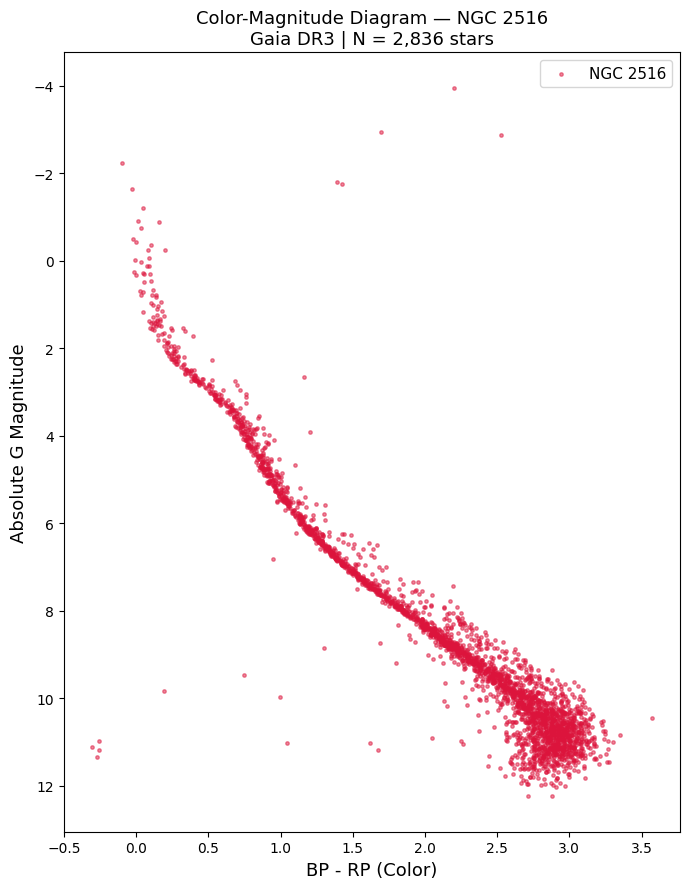

Saved cmd_ngc2516.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 9))

ax.scatter(df_n['bp_rp'], df_n['abs_mag'],
           s=6, alpha=0.5, color='crimson', label='NGC 2516')

ax.set_xlabel('BP - RP (Color)', fontsize=13)
ax.set_ylabel('Absolute G Magnitude', fontsize=13)
ax.set_title('Color-Magnitude Diagram — NGC 2516\nGaia DR3 | N = 2,836 stars', fontsize=13)
ax.invert_yaxis()
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('cmd_ngc2516.png', dpi=150)
plt.show()
print("Saved cmd_ngc2516.png")

In [ ]:
query_blanco1 = """
SELECT
    source_id, ra, dec,
    parallax, parallax_error,
    pmra, pmra_error,
    pmdec, pmdec_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    bp_rp, ruwe
FROM gaiadr3.gaia_source
WHERE CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', 1.07, -29.51, 2.5)
) = 1
AND parallax IS NOT NULL
AND phot_g_mean_mag IS NOT NULL
AND bp_rp IS NOT NULL
"""

job = Gaia.launch_job_async(query_blanco1)
results = job.get_results()
df_blanco1_raw = results.to_pandas()

print(f"Raw query returned: {len(df_blanco1_raw)} stars")
df_blanco1_raw.head()

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Raw query returned: 49730 stars


,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,ruwe
0,2313652982041172224,1.734328,-31.842667,2.349589,0.174374,-0.169111,0.186445,-2.227329,0.163572,18.494814,19.720898,17.370214,2.350683,1.121207
1,2313653561860442752,1.796106,-31.779615,2.621225,0.054055,-24.908313,0.057965,-11.793230,0.045569,16.562681,17.687708,15.509372,2.178336,1.051840
2,2313653768019333120,1.739254,-31.763999,0.834438,0.503871,7.059590,0.679988,-4.181323,0.507913,20.121559,21.105934,19.032436,2.073498,1.027590
3,2313671188406596096,1.238370,-31.960296,0.705993,0.083170,7.590295,0.066992,-2.892580,0.061589,16.838051,17.280687,16.223410,1.057278,0.987159
4,2313678988067188480,0.910662,-31.995901,1.073929,0.520740,-6.773921,0.646239,-15.830055,0.406242,19.837458,21.586235,18.736475,2.849760,0.968221


In [ ]:
df_b = df_blanco1_raw.copy()

df_b = df_b[df_b['parallax_error'] / df_b['parallax'] < 0.1]
df_b = df_b[df_b['ruwe'] < 1.4]
df_b = df_b.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
print(f"After quality cuts: {len(df_b)} stars")

df_b = df_b[(df_b['parallax'] >= 3.4) & (df_b['parallax'] <= 5.0)]
print(f"After parallax cut: {len(df_b)} stars")

df_b = df_b[(df_b['pmra'] >= 15.7) & (df_b['pmra'] <= 21.7)]
df_b = df_b[(df_b['pmdec'] >= -0.3) & (df_b['pmdec'] <= 5.7)]
print(f"After proper motion cut: {len(df_b)} stars")

df_b['distance_pc'] = 1000 / df_b['parallax']
df_b['abs_mag'] = df_b['phot_g_mean_mag'] - 5 * np.log10(df_b['distance_pc']) + 5

df_b.to_csv('blanco1_clean.csv', index=False)
print(f"\nSaved blanco1_clean.csv")
print(df_b[['parallax','pmra','pmdec','bp_rp','phot_g_mean_mag']].describe())

After quality cuts: 18210 stars
After parallax cut: 1549 stars
After proper motion cut: 597 stars

Saved blanco1_clean.csv
         parallax        pmra       pmdec       bp_rp  phot_g_mean_mag
count  597.000000  597.000000  597.000000  597.000000       597.000000
mean     4.221873   18.738169    2.617440    2.507889        16.677813
std      0.185911    0.472038    0.483036    0.824072         2.516919
min      3.423856   15.866784   -0.035418   -0.076627         7.756221
25%      4.157282   18.424456    2.339120    2.261456        15.865607
50%      4.229224   18.747883    2.615236    2.867256        17.557852
75%      4.314307   19.025008    2.878840    3.026073        18.431763
max      4.969922   20.729502    5.673645    3.679203        19.926737


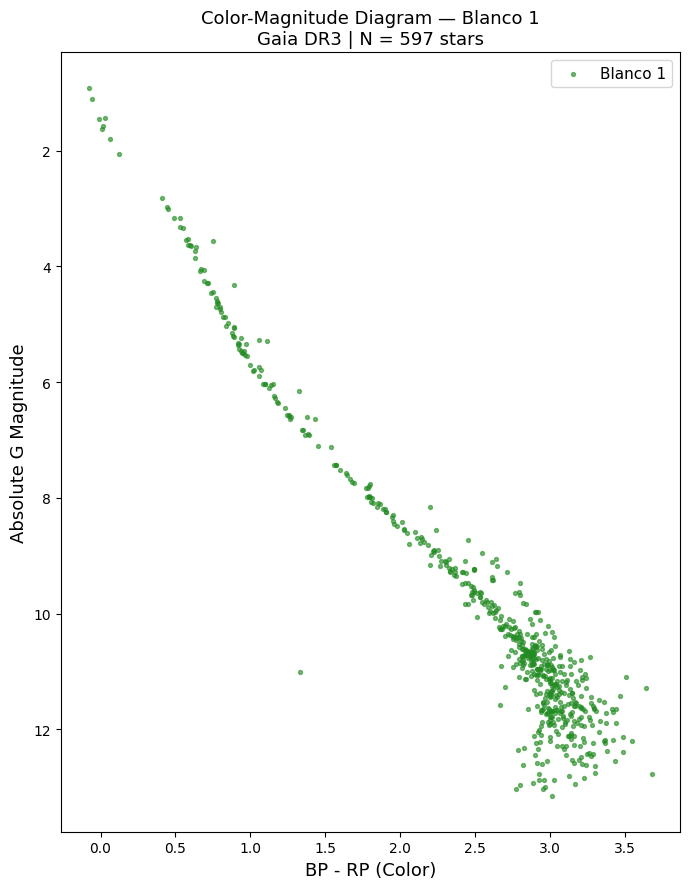

Saved cmd_blanco1.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 9))

ax.scatter(df_b['bp_rp'], df_b['abs_mag'],
           s=8, alpha=0.6, color='forestgreen', label='Blanco 1')

ax.set_xlabel('BP - RP (Color)', fontsize=13)
ax.set_ylabel('Absolute G Magnitude', fontsize=13)
ax.set_title('Color-Magnitude Diagram — Blanco 1\nGaia DR3 | N = 597 stars', fontsize=13)
ax.invert_yaxis()
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('cmd_blanco1.png', dpi=150)
plt.show()
print("Saved cmd_blanco1.png")

In [ ]:
import os
print(os.listdir('.'))

['.config', 'ngc2516_clean.csv', 'praesepe_clean.csv', 'cmd_praesepe.png', 'cmd_blanco1.png', 'blanco1_clean.csv', 'cmd_ngc2516.png', 'sample_data']


In [ ]:
query_pleiades = """
SELECT
    source_id, ra, dec,
    parallax, parallax_error,
    pmra, pmra_error,
    pmdec, pmdec_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    bp_rp, ruwe
FROM gaiadr3.gaia_source
WHERE CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', 56.75, 24.12, 3.0)
) = 1
AND parallax IS NOT NULL
AND phot_g_mean_mag IS NOT NULL
AND bp_rp IS NOT NULL
"""

job = Gaia.launch_job_async(query_pleiades)
results = job.get_results()
df_pl_raw = results.to_pandas()
print(f"Pleiades raw: {len(df_pl_raw)} stars")

df_pl = df_pl_raw.copy()
df_pl = df_pl[df_pl['parallax_error'] / df_pl['parallax'] < 0.1]
df_pl = df_pl[df_pl['ruwe'] < 1.4]
df_pl = df_pl.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
df_pl = df_pl[(df_pl['parallax'] >= 6.0) & (df_pl['parallax'] <= 9.0)]
df_pl = df_pl[(df_pl['pmra'] >= 17.0) & (df_pl['pmra'] <= 23.0)]
df_pl = df_pl[(df_pl['pmdec'] >= -48.0) & (df_pl['pmdec'] <= -42.0)]

df_pl['distance_pc'] = 1000 / df_pl['parallax']
df_pl['abs_mag'] = df_pl['phot_g_mean_mag'] - 5 * np.log10(df_pl['distance_pc']) + 5

df_pl.to_csv('pleiades_clean.csv', index=False)
print(f"Pleiades clean: {len(df_pl)} stars")

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Pleiades raw: 219733 stars
Pleiades clean: 1055 stars


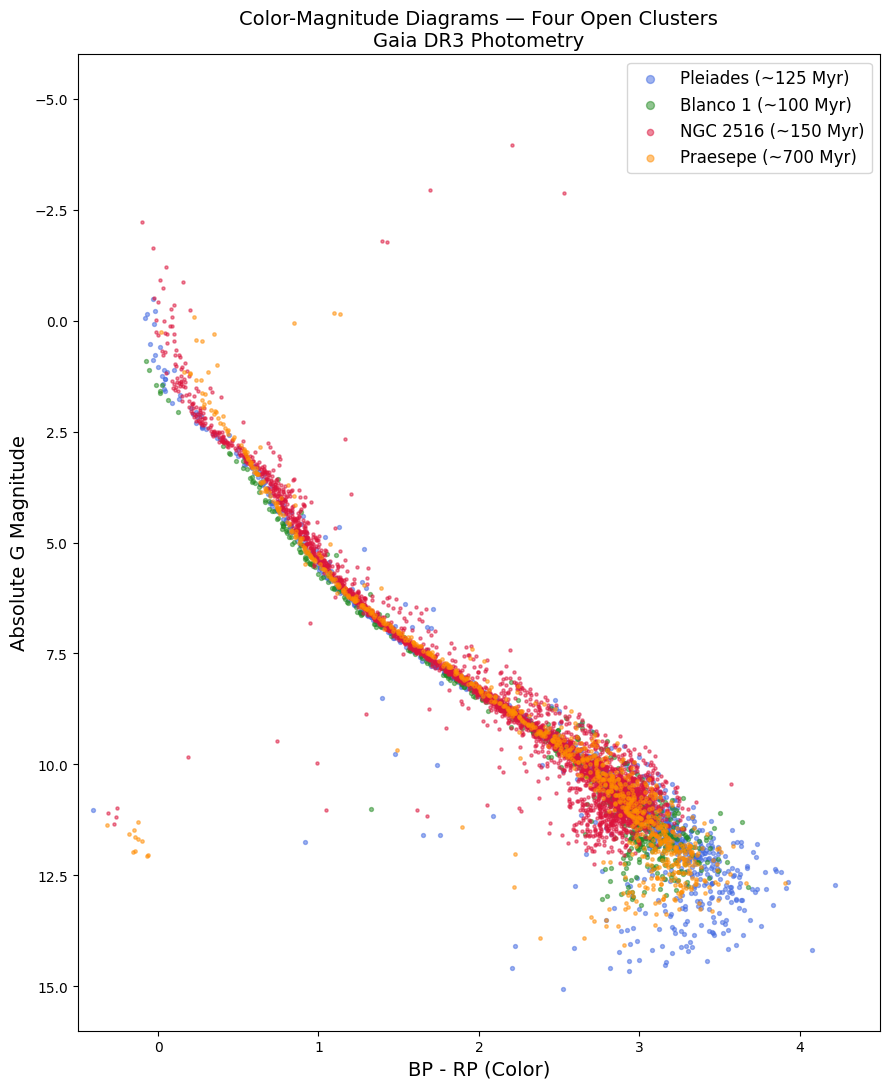

Saved cmd_overlay_4clusters.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 11))

clusters = [
    (df_pl,  'Pleiades (~125 Myr)',  'royalblue',  8),
    (df_b,   'Blanco 1 (~100 Myr)', 'forestgreen', 8),
    (df_n,   'NGC 2516 (~150 Myr)', 'crimson',     5),
    (df_p,   'Praesepe (~700 Myr)', 'darkorange',  6),
]

for df, label, color, size in clusters:
    ax.scatter(df['bp_rp'], df['abs_mag'],
               s=size, alpha=0.5, color=color, label=label)

ax.set_xlabel('BP - RP (Color)', fontsize=14)
ax.set_ylabel('Absolute G Magnitude', fontsize=14)
ax.set_title('Color-Magnitude Diagrams — Four Open Clusters\nGaia DR3 Photometry', fontsize=14)
ax.invert_yaxis()
ax.legend(fontsize=12, markerscale=2)
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(16, -6)
plt.tight_layout()
plt.savefig('cmd_overlay_4clusters.png', dpi=150)
plt.show()
print("Saved cmd_overlay_4clusters.png")

In [ ]:
!pip install astroquery astropy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from astroquery.gaia import Gaia

def query_and_clean(ra, dec, radius, plx_min, plx_max, pmra_min, pmra_max, pmdec_min, pmdec_max, name):
    query = f"""
    SELECT source_id, ra, dec, parallax, parallax_error,
           pmra, pmra_error, pmdec, pmdec_error,
           phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp, ruwe
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius})) = 1
    AND parallax IS NOT NULL AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
    """
    job = Gaia.launch_job_async(query)
    df = job.get_results().to_pandas()
    df = df[df['parallax_error'] / df['parallax'] < 0.1]
    df = df[df['ruwe'] < 1.4]
    df = df.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
    df = df[(df['parallax'] >= plx_min) & (df['parallax'] <= plx_max)]
    df = df[(df['pmra'] >= pmra_min) & (df['pmra'] <= pmra_max)]
    df = df[(df['pmdec'] >= pmdec_min) & (df['pmdec'] <= pmdec_max)]
    df['distance_pc'] = 1000 / df['parallax']
    df['abs_mag'] = df['phot_g_mean_mag'] - 5 * np.log10(df['distance_pc']) + 5
    df.to_csv(f'{name}_clean.csv', index=False)
    print(f"{name}: {len(df)} stars")
    return df

df_pl = query_and_clean(56.75, 24.12, 3.0, 6.0, 9.0, 17.0, 23.0, -48.0, -42.0, 'pleiades')
df_p  = query_and_clean(130.05, 19.67, 3.0, 4.5, 6.5, -38.7, -32.7, -15.9, -9.9, 'praesepe')
df_n  = query_and_clean(119.52, -60.75, 2.0, 1.9, 3.0, -7.7, -1.7, 8.2, 14.2, 'ngc2516')
df_b  = query_and_clean(1.07, -29.51, 2.5, 3.4, 5.0, 15.7, 21.7, -0.3, 5.7, 'blanco1')

print("\nAll data ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.5 MB/s eta 0:00:00
In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
pleiades: 1055 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
praesepe: 921 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
ngc2516: 2836 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
blanco1: 597 stars

All data ready.


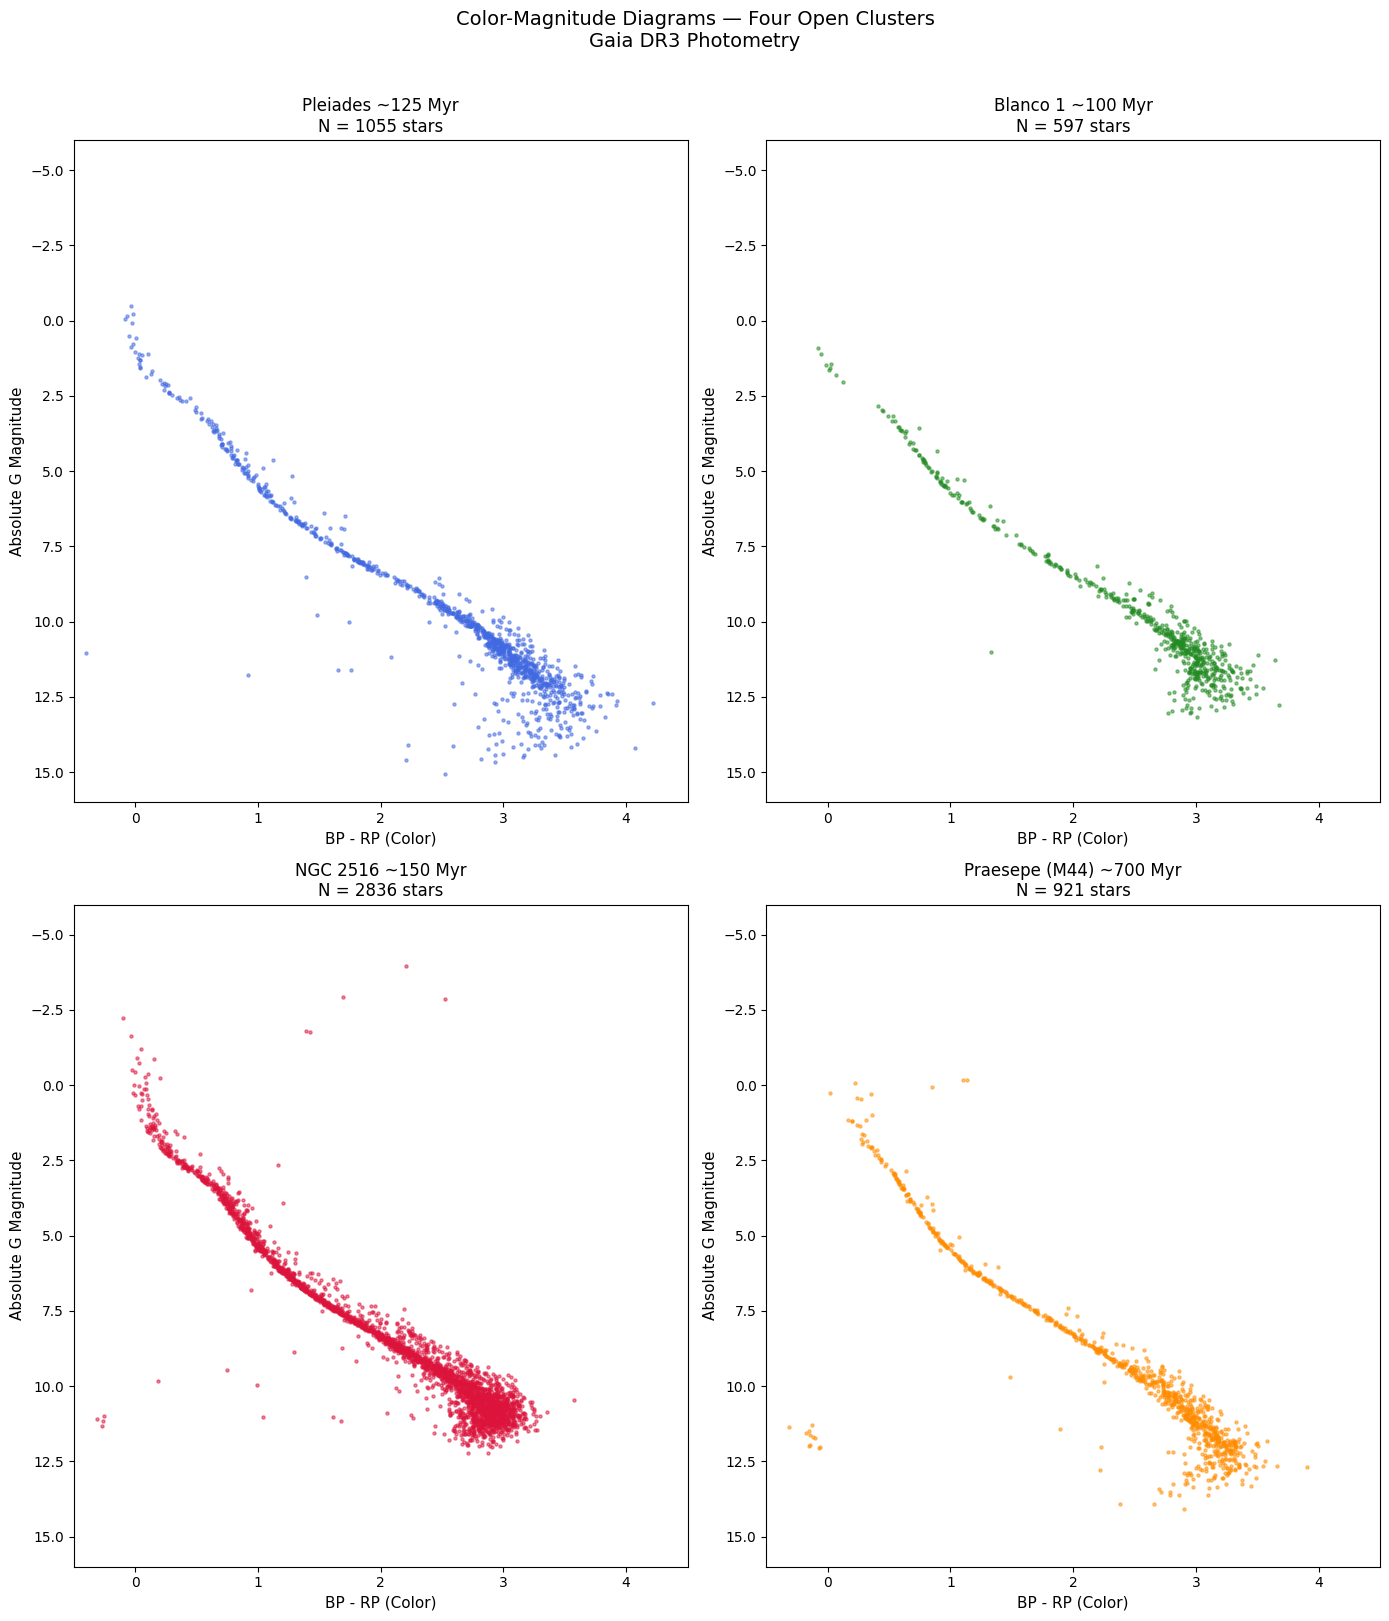

Saved cmd_4panel.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

panel_info = [
    (df_pl, 'Pleiades ~125 Myr',        'royalblue',  1055),
    (df_b,  'Blanco 1 ~100 Myr',        'forestgreen', 597),
    (df_n,  'NGC 2516 ~150 Myr',        'crimson',    2836),
    (df_p,  'Praesepe (M44) ~700 Myr',  'darkorange',  921),
]

for ax, (df, title, color, n) in zip(axes, panel_info):
    ax.scatter(df['bp_rp'], df['abs_mag'],
               s=5, alpha=0.5, color=color)
    ax.set_xlabel('BP - RP (Color)', fontsize=11)
    ax.set_ylabel('Absolute G Magnitude', fontsize=11)
    ax.set_title(f'{title}\nN = {n} stars', fontsize=12)
    ax.invert_yaxis()
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(16, -6)

plt.suptitle('Color-Magnitude Diagrams — Four Open Clusters\nGaia DR3 Photometry',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('cmd_4panel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved cmd_4panel.png")

## Step 6 Results — CMD Overlay Observations

- Four clusters aligned on a common main sequence
- Praesepe (700 Myr) shows earlier main sequence turnoff than younger clusters (~100-150 Myr)
- NGC 2516 contains apparent giant/supergiant stars above the main sequence (abs mag < 0)
- White dwarf candidates visible at BP-RP ~ -0.3, abs mag ~ 11
- Cluster main sequences consistent with known ages - validates cleaning pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

features = ['bp_rp', 'abs_mag', 'pmra', 'pmdec', 'parallax']
X = df_p[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}  silhouette={score:.4f}")

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k: {best_k}")

k=2  silhouette=0.3073
k=3  silhouette=0.2491
k=4  silhouette=0.2295
k=5  silhouette=0.2386
k=6  silhouette=0.2340

Best k: 2


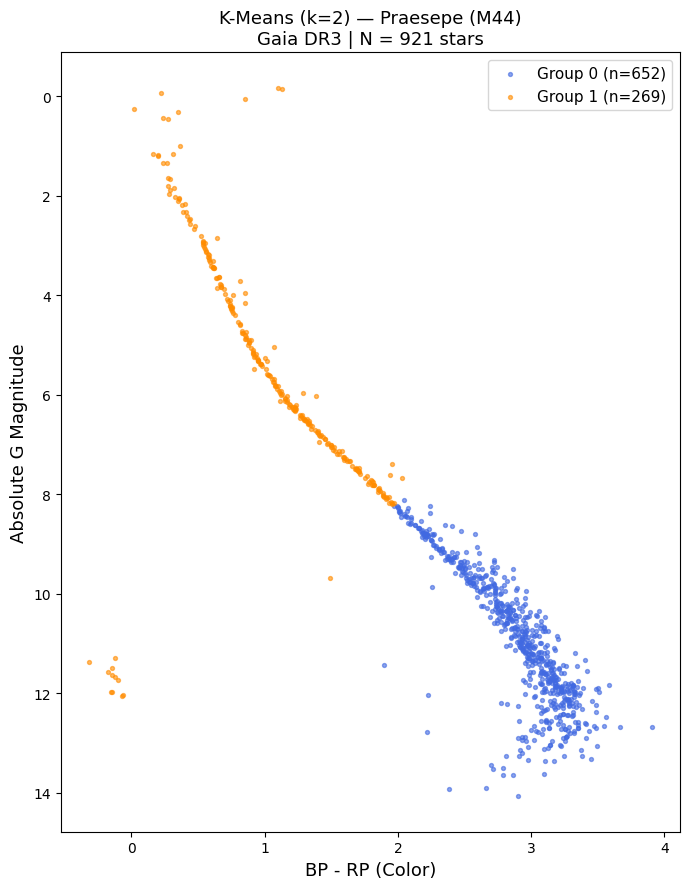


Group statistics:
              bp_rp  abs_mag    pmra   pmdec  parallax
kmeans_label                                          
0             2.885   10.921 -35.918 -12.869     5.399
1             1.029    5.514 -35.884 -12.858     5.412


In [ ]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_p['kmeans_label'] = km_final.fit_predict(X_scaled)

colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson', 'purple']
labels_names = ['Group 0', 'Group 1', 'Group 2', 'Group 3', 'Group 4']

fig, ax = plt.subplots(figsize=(7, 9))

for i in range(best_k):
    mask = df_p['kmeans_label'] == i
    ax.scatter(df_p.loc[mask, 'bp_rp'],
               df_p.loc[mask, 'abs_mag'],
               s=8, alpha=0.6,
               color=colors[i],
               label=f'Group {i} (n={mask.sum()})')

ax.set_xlabel('BP - RP (Color)', fontsize=13)
ax.set_ylabel('Absolute G Magnitude', fontsize=13)
ax.set_title(f'K-Means (k={best_k}) — Praesepe (M44)\nGaia DR3 | N = 921 stars', fontsize=13)
ax.invert_yaxis()
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('kmeans_praesepe.png', dpi=150)
plt.show()

print("\nGroup statistics:")
print(df_p.groupby('kmeans_label')[features].mean().round(3))

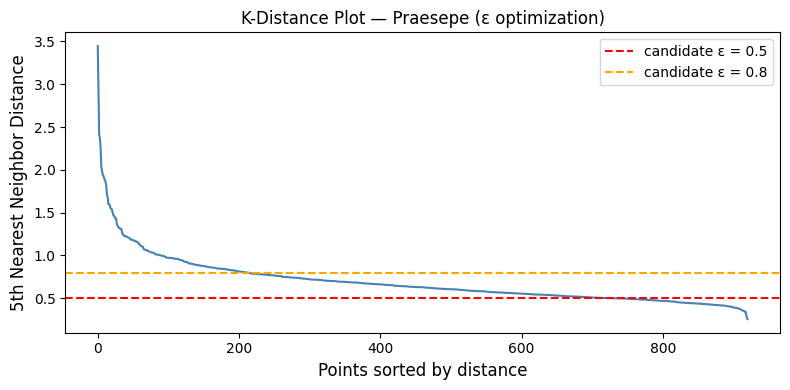

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_distances, color='steelblue', linewidth=1.5)
ax.set_xlabel('Points sorted by distance', fontsize=12)
ax.set_ylabel('5th Nearest Neighbor Distance', fontsize=12)
ax.set_title('K-Distance Plot — Praesepe (ε optimization)', fontsize=12)
ax.axhline(y=0.5, color='red', linestyle='--', label='candidate ε = 0.5')
ax.axhline(y=0.8, color='orange', linestyle='--', label='candidate ε = 0.8')
ax.legend()
plt.tight_layout()
plt.savefig('kdistance_praesepe.png', dpi=150)
plt.show()

In [ ]:
for eps_val in [0.5, 0.6, 0.7, 0.8, 0.9]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    labels = db.fit_predict(X_scaled)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"ε={eps_val}  →  clusters={n_clust}  noise={n_noise}")

ε=0.5  →  clusters=17  noise=564
ε=0.6  →  clusters=10  noise=333
ε=0.7  →  clusters=5  noise=195
ε=0.8  →  clusters=1  noise=113
ε=0.9  →  clusters=3  noise=60


Clusters found: 5
Noise points: 195

Label counts:
dbscan_label
-1    195
 0    703
 1      5
 2     11
 3      2
 4      5
Name: count, dtype: int64


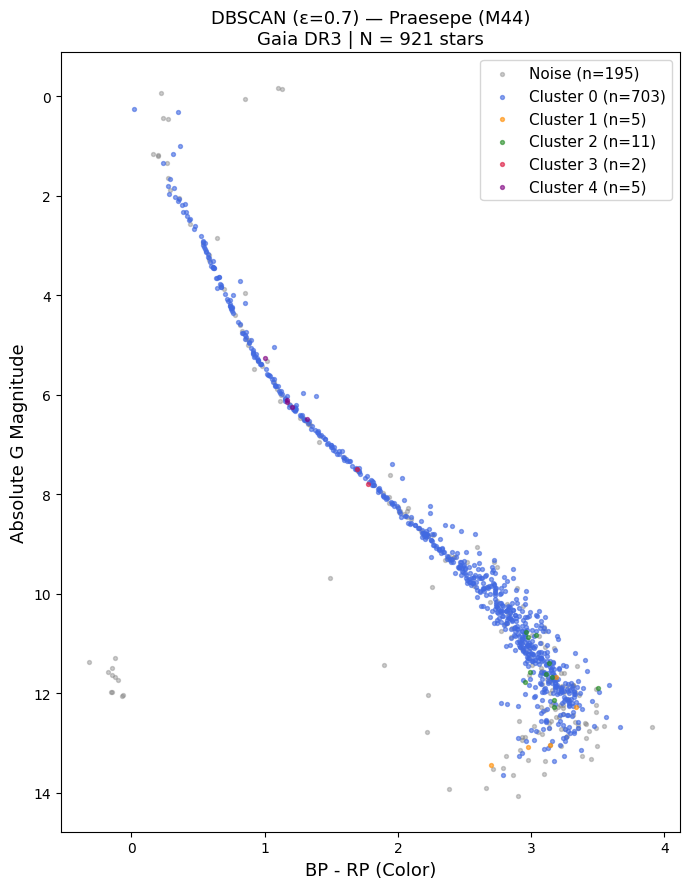


Cluster statistics:
              bp_rp  abs_mag    pmra   pmdec  parallax
dbscan_label                                          
-1            2.241    9.643 -35.820 -12.831     5.397
 0            2.365    9.228 -35.953 -12.873     5.413
 1            3.067   12.701 -36.492 -12.339     5.064
 2            3.106   11.525 -34.478 -12.290     5.011
 3            1.736    7.638 -36.577 -14.198     5.447
 4            1.171    6.051 -35.438 -14.426     5.406


In [ ]:
dbscan = DBSCAN(eps=0.7, min_samples=5)
df_p['dbscan_label'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df_p['dbscan_label'])) - (1 if -1 in df_p['dbscan_label'].values else 0)
n_noise = (df_p['dbscan_label'] == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")
print(f"\nLabel counts:")
print(df_p['dbscan_label'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 9))

mask_noise = df_p['dbscan_label'] == -1
ax.scatter(df_p.loc[mask_noise, 'bp_rp'],
           df_p.loc[mask_noise, 'abs_mag'],
           s=8, alpha=0.4, color='grey', label=f'Noise (n={mask_noise.sum()})')

colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson', 'purple']
for i in range(n_clusters):
    mask = df_p['dbscan_label'] == i
    ax.scatter(df_p.loc[mask, 'bp_rp'],
               df_p.loc[mask, 'abs_mag'],
               s=8, alpha=0.6, color=colors[i],
               label=f'Cluster {i} (n={mask.sum()})')

ax.set_xlabel('BP - RP (Color)', fontsize=13)
ax.set_ylabel('Absolute G Magnitude', fontsize=13)
ax.set_title(f'DBSCAN (ε=0.7) — Praesepe (M44)\nGaia DR3 | N = 921 stars', fontsize=13)
ax.invert_yaxis()
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('dbscan_praesepe.png', dpi=150)
plt.show()

print("\nCluster statistics:")
print(df_p.groupby('dbscan_label')[features].mean().round(3))

### DBSCAN Results — Praesepe (M44)
- ε = 0.7 selected via k-distance elbow method and sensitivity analysis (ε = 0.5–0.9)
- 5 clusters found, but Cluster 0 contains 703/921 stars (76%)
- Minor clusters (n=2–11) likely represent localized CMD overdensities, not distinct populations
- 195 noise points include white dwarf candidates (BP-RP ~ -0.3, abs mag ~ 11–12)
- Interpretation: Praesepe's main sequence is a continuous structure —
  no strong discrete subpopulation signal detected at this feature resolution

n=2  BIC=10271.02
n=3  BIC=9209.77
n=4  BIC=8842.93
n=5  BIC=8274.67
n=6  BIC=8311.61

Best n_components: 5


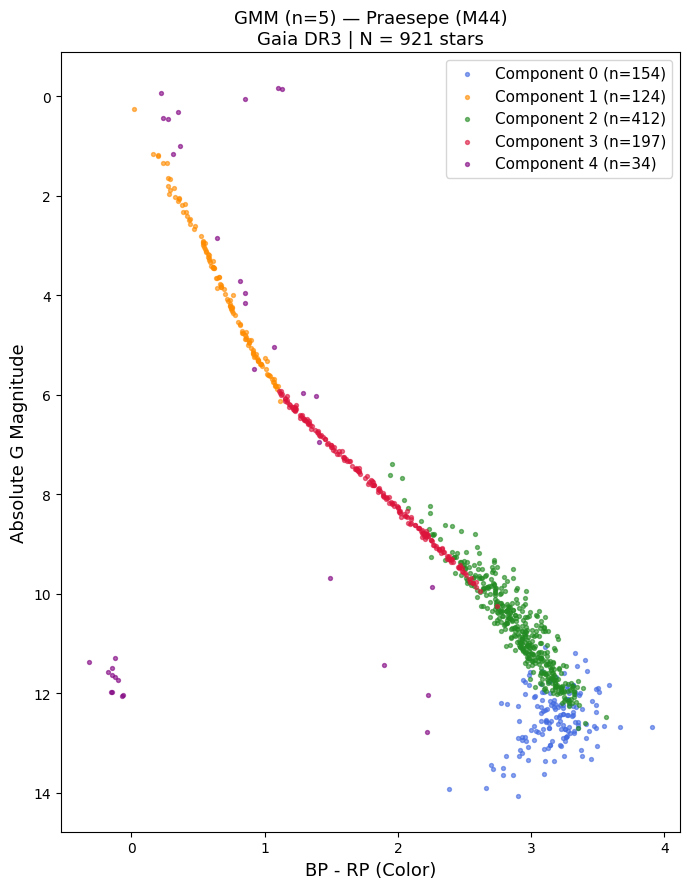


GMM component statistics:
           bp_rp  abs_mag    pmra   pmdec  parallax
gmm_label                                          
0          3.177   12.507 -36.004 -12.928     5.437
1          0.702    3.918 -36.011 -12.807     5.421
2          2.903   10.694 -35.883 -12.822     5.383
3          1.844    7.890 -35.795 -12.959     5.414
4          0.664    6.812 -36.069 -12.782     5.364


In [ ]:
from sklearn.mixture import GaussianMixture

bic_scores = []
n_range = range(2, 7)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm.fit(X_scaled)
    bic = gmm.bic(X_scaled)
    bic_scores.append(bic)
    print(f"n={n}  BIC={bic:.2f}")

best_n = n_range[bic_scores.index(min(bic_scores))]
print(f"\nBest n_components: {best_n}")

gmm_final = GaussianMixture(n_components=best_n, random_state=42, n_init=5)
df_p['gmm_label'] = gmm_final.fit_predict(X_scaled)
fig, ax = plt.subplots(figsize=(7, 9))
colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson', 'purple']

for i in range(best_n):
    mask = df_p['gmm_label'] == i
    ax.scatter(df_p.loc[mask, 'bp_rp'],
               df_p.loc[mask, 'abs_mag'],
               s=8, alpha=0.6, color=colors[i],
               label=f'Component {i} (n={mask.sum()})')

ax.set_xlabel('BP - RP (Color)', fontsize=13)
ax.set_ylabel('Absolute G Magnitude', fontsize=13)
ax.set_title(f'GMM (n={best_n}) — Praesepe (M44)\nGaia DR3 | N = 921 stars', fontsize=13)
ax.invert_yaxis()
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('gmm_praesepe.png', dpi=150)
plt.show()

print("\nGMM component statistics:")
print(df_p.groupby('gmm_label')[features].mean().round(3))

### GMM Results — Praesepe (M44)
- BIC minimized at n=5 components
- Components map onto physically distinct mass regimes along the main sequence:
  - Component 1: upper MS / turnoff (BP-RP~0.70, M_G~3.9)
  - Component 4: mid MS (BP-RP~0.66, M_G~6.8)  
  - Component 3: solar-type stars (BP-RP~1.84, M_G~7.9)
  - Component 2: K-type lower MS (BP-RP~2.90, M_G~10.7)
  - Component 0: M-dwarfs + outliers (BP-RP~3.18, M_G~12.5)
- All three algorithms consistent: main sequence is continuous,
  no sharp discrete subpopulation boundaries detected

### GMM Caveat — Component 4
- Component 4 (n=34) is spatially incoherent on the CMD
- Stars scattered across white dwarf region and upper main sequence
- Likely captures kinematic similarity rather than evolutionary coherence
- Illustrates GMM limitation: components are defined in full 5D feature space,
  not CMD space alone — physical interpretation requires caution
- This component excluded from evolutionary stage classification

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

features = ['bp_rp', 'abs_mag', 'pmra', 'pmdec', 'parallax']

cluster_data = {
    'Pleiades':  df_pl,
    'NGC 2516':  df_n,
    'Blanco 1':  df_b,
}

results_summary = {}

for name, df in cluster_data.items():
    print(f"\n{'='*50}")
    print(f"  {name}  (N={len(df)})")
    print(f"{'='*50}")

    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    sil_scores = []
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        sil_scores.append(silhouette_score(X_scaled, labels))
    best_k = range(2, 7)[sil_scores.index(max(sil_scores))]
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df['kmeans_label'] = km_final.fit_predict(X_scaled)
    print(f"\nK-Means → best k={best_k}  (silhouette={max(sil_scores):.4f})")
    print(df.groupby('kmeans_label')[['bp_rp','abs_mag']].mean().round(3))

    print(f"\nDBSCAN sensitivity:")
    best_eps, best_eps_clusters = 0.7, 0
    for eps_val in [0.5, 0.6, 0.7, 0.8, 0.9]:
        db = DBSCAN(eps=eps_val, min_samples=5)
        labels = db.fit_predict(X_scaled)
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        n_no = (labels == -1).sum()
        print(f"  ε={eps_val} → clusters={n_cl}  noise={n_no}")
        if n_cl >= 2 and n_cl <= 6:
            best_eps = eps_val
            best_eps_clusters = n_cl
    db_final = DBSCAN(eps=best_eps, min_samples=5)
    df['dbscan_label'] = db_final.fit_predict(X_scaled)
    n_noise = (df['dbscan_label'] == -1).sum()
    print(f"  Selected ε={best_eps} → clusters={best_eps_clusters}  noise={n_noise}")

    bic_scores = []
    for n in range(2, 7):
        gmm = GaussianMixture(n_components=n, random_state=42, n_init=5)
        gmm.fit(X_scaled)
        bic_scores.append(gmm.bic(X_scaled))
    best_n = range(2, 7)[bic_scores.index(min(bic_scores))]
    gmm_final = GaussianMixture(n_components=best_n, random_state=42, n_init=5)
    df['gmm_label'] = gmm_final.fit_predict(X_scaled)
    print(f"\nGMM → best n={best_n}  (BIC={min(bic_scores):.2f})")
    print(df.groupby('gmm_label')[['bp_rp','abs_mag']].mean().round(3))

    results_summary[name] = {
        'N': len(df),
        'kmeans_k': best_k,
        'dbscan_eps': best_eps,
        'dbscan_clusters': best_eps_clusters,
        'gmm_n': best_n
    }

print(f"\n{'='*50}")
print("SUMMARY TABLE")
print(f"{'='*50}")
for name, r in results_summary.items():
    print(f"{name}: N={r['N']}  k-means k={r['kmeans_k']}  "
          f"DBSCAN ε={r['dbscan_eps']} clusters={r['dbscan_clusters']}  "
          f"GMM n={r['gmm_n']}")


  Pleiades  (N=1055)

K-Means → best k=2  (silhouette=0.3369)
              bp_rp  abs_mag
kmeans_label                
0             1.102    5.531
1             3.038   11.294

DBSCAN sensitivity:
  ε=0.5 → clusters=11  noise=529
  ε=0.6 → clusters=7  noise=328
  ε=0.7 → clusters=4  noise=189
  ε=0.8 → clusters=2  noise=103
  ε=0.9 → clusters=2  noise=62
  Selected ε=0.9 → clusters=2  noise=62

GMM → best n=6  (BIC=9476.49)
           bp_rp  abs_mag
gmm_label                
0          3.067   11.181
1          1.149    6.822
2          2.217    8.856
3          0.802    4.475
4          3.239   11.532
5          3.288   13.445

  NGC 2516  (N=2836)

K-Means → best k=2  (silhouette=0.3310)
              bp_rp  abs_mag
kmeans_label                
0             0.979    4.926
1             2.615    9.976

DBSCAN sensitivity:
  ε=0.5 → clusters=3  noise=620
  ε=0.6 → clusters=2  noise=423
  ε=0.7 → clusters=2  noise=341
  ε=0.8 → clusters=1  noise=279
  ε=0.9 → clusters=1  noise=235
 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

cluster_info = [
    (df_p,  'Praesepe (M44) ~700 Myr',  'gmm_label', 5),
    (df_pl, 'Pleiades ~125 Myr',         'gmm_label', 6),
    (df_n,  'NGC 2516 ~150 Myr',         'gmm_label', 6),
    (df_b,  'Blanco 1 ~100 Myr',         'gmm_label', 5),
]

colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson', 'purple', 'brown']

for ax, (df, title, label_col, n_comp) in zip(axes, cluster_info):
    for i in range(n_comp):
        mask = df[label_col] == i
        ax.scatter(df.loc[mask, 'bp_rp'],
                   df.loc[mask, 'abs_mag'],
                   s=5, alpha=0.6, color=colors[i],
                   label=f'Component {i} (n={mask.sum()})')
    ax.set_xlabel('BP - RP (Color)', fontsize=11)
    ax.set_ylabel('Absolute G Magnitude', fontsize=11)
    ax.set_title(f'GMM — {title}', fontsize=11)
    ax.invert_yaxis()
    ax.legend(fontsize=7, markerscale=2)
    ax.set_xlim(-0.5, 4.5)

plt.suptitle('GMM Stellar Population Classification — Four Open Clusters\nGaia DR3 Photometry',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('gmm_4panel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved gmm_4panel.png")

NameError: name 'plt' is not defined

In [ ]:
!pip install astroquery astropy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from astroquery.gaia import Gaia

# Reload all four cleaned CSVs
df_pl = pd.read_csv('pleiades_clean.csv')
df_p  = pd.read_csv('praesepe_clean.csv')
df_n  = pd.read_csv('ngc2516_clean.csv')
df_b  = pd.read_csv('blanco1_clean.csv')

print(f"Pleiades: {len(df_pl)} | Praesepe: {len(df_p)} | NGC 2516: {len(df_n)} | Blanco 1: {len(df_b)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.2 MB/s eta 0:00:00
In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


FileNotFoundError: [Errno 2] No such file or directory: 'pleiades_clean.csv'

In [ ]:
from astroquery.gaia import Gaia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

def query_and_clean(ra, dec, radius, plx_min, plx_max, pmra_min, pmra_max, pmdec_min, pmdec_max, name):
    query = f"""
    SELECT source_id, ra, dec, parallax, parallax_error,
           pmra, pmra_error, pmdec, pmdec_error,
           phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp, ruwe
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius})) = 1
    AND parallax IS NOT NULL AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
    """
    job = Gaia.launch_job_async(query)
    df = job.get_results().to_pandas()
    df = df[df['parallax_error'] / df['parallax'] < 0.1]
    df = df[df['ruwe'] < 1.4]
    df = df.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
    df = df[(df['parallax'] >= plx_min) & (df['parallax'] <= plx_max)]
    df = df[(df['pmra'] >= pmra_min) & (df['pmra'] <= pmra_max)]
    df = df[(df['pmdec'] >= pmdec_min) & (df['pmdec'] <= pmdec_max)]
    df['distance_pc'] = 1000 / df['parallax']
    df['abs_mag'] = df['phot_g_mean_mag'] - 5 * np.log10(df['distance_pc']) + 5
    df.to_csv(f'{name}_clean.csv', index=False)
    print(f"{name}: {len(df)} stars")
    return df

df_pl = query_and_clean(56.75, 24.12, 3.0, 6.0, 9.0, 17.0, 23.0, -48.0, -42.0, 'pleiades')
df_p  = query_and_clean(130.05, 19.67, 3.0, 4.5, 6.5, -38.7, -32.7, -15.9, -9.9, 'praesepe')
df_n  = query_and_clean(119.52, -60.75, 2.0, 1.9, 3.0, -7.7, -1.7, 8.2, 14.2, 'ngc2516')
df_b  = query_and_clean(1.07, -29.51, 2.5, 3.4, 5.0, 15.7, 21.7, -0.3, 5.7, 'blanco1')

print("\nAll four clusters ready.")


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
pleiades: 1055 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
praesepe: 921 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
ngc2516: 2836 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
blanco1: 597 stars

All four clusters ready.


ML complete. Building 4-panel figure...


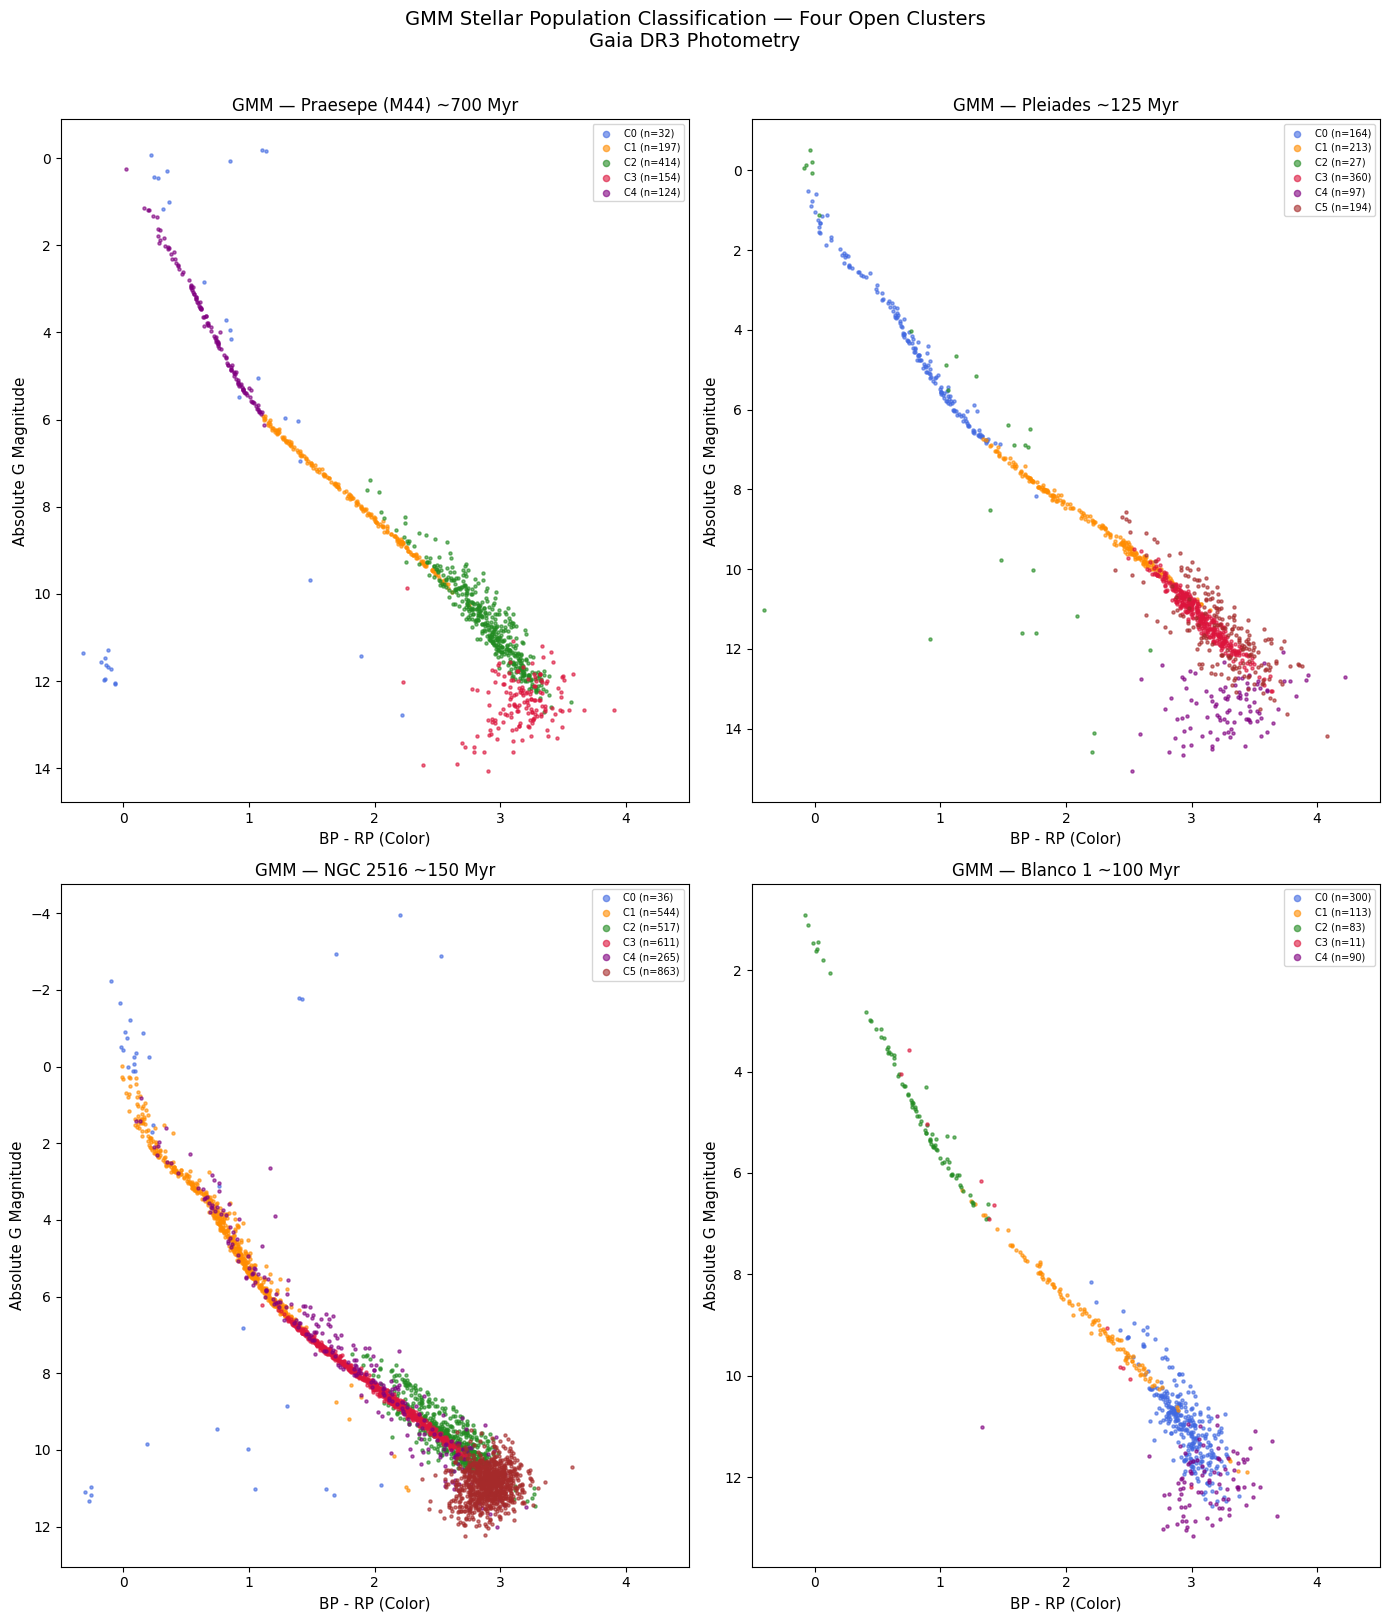

Saved gmm_4panel.png


In [ ]:
features = ['bp_rp', 'abs_mag', 'pmra', 'pmdec', 'parallax']

cluster_data = {
    'Praesepe':  (df_p,  5),
    'Pleiades':  (df_pl, 6),
    'NGC 2516':  (df_n,  6),
    'Blanco 1':  (df_b,  5),
}

for name, (df, gmm_n) in cluster_data.items():
    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    sil_scores = []
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        sil_scores.append(silhouette_score(X_scaled, km.fit_predict(X_scaled)))
    best_k = range(2, 7)[sil_scores.index(max(sil_scores))]
    df['kmeans_label'] = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_scaled)

    best_eps = 0.7
    for eps_val in [0.5, 0.6, 0.7, 0.8, 0.9]:
        db = DBSCAN(eps=eps_val, min_samples=5)
        labels = db.fit_predict(X_scaled)
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        if 2 <= n_cl <= 6:
            best_eps = eps_val
    df['dbscan_label'] = DBSCAN(eps=best_eps, min_samples=5).fit_predict(X_scaled)

    gmm_final = GaussianMixture(n_components=gmm_n, random_state=42, n_init=5)
    df['gmm_label'] = gmm_final.fit_predict(X_scaled)

print("ML complete. Building 4-panel figure...")

fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()
colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson', 'purple', 'brown']

panel_info = [
    (df_p,  'Praesepe (M44) ~700 Myr', 5),
    (df_pl, 'Pleiades ~125 Myr',        6),
    (df_n,  'NGC 2516 ~150 Myr',        6),
    (df_b,  'Blanco 1 ~100 Myr',        5),
]

for ax, (df, title, n_comp) in zip(axes, panel_info):
    for i in range(n_comp):
        mask = df['gmm_label'] == i
        ax.scatter(df.loc[mask, 'bp_rp'],
                   df.loc[mask, 'abs_mag'],
                   s=5, alpha=0.6, color=colors[i],
                   label=f'C{i} (n={mask.sum()})')
    ax.set_xlabel('BP - RP (Color)', fontsize=11)
    ax.set_ylabel('Absolute G Magnitude', fontsize=11)
    ax.set_title(f'GMM — {title}', fontsize=12)
    ax.invert_yaxis()
    ax.legend(fontsize=7, markerscale=2)
    ax.set_xlim(-0.5, 4.5)

plt.suptitle('GMM Stellar Population Classification — Four Open Clusters\nGaia DR3 Photometry',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('gmm_4panel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved gmm_4panel.png")

In [ ]:
df_p.to_csv('praesepe_ml.csv', index=False)
df_pl.to_csv('pleiades_ml.csv', index=False)
df_n.to_csv('ngc2516_ml.csv', index=False)
df_b.to_csv('blanco1_ml.csv', index=False)
print("All ML results saved.")

All ML results saved.


In [ ]:
import os
files = [f for f in os.listdir('.') if 'isochrone' in f or '.dat' in f]
print(files)

['ngc2516_isochrone.dat', 'praesepe_isochrone.dat', 'pleiades_isochrone.dat', 'blanco1_isochrone.dat']


In [ ]:
import numpy as np

def load_isochrone(filepath):
    """Load PARSEC isochrone, skip comment lines starting with #"""
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#') or line.strip() == '':
                continue
            data.append(line.split())
    df_iso = pd.DataFrame(data)
    return df_iso

def load_isochrone_properly(filepath):
    cols = None
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                if 'Gmag' in line or 'G_BPmag' in line:
                    cols = line.strip('#').split()
            else:
                if line.strip():
                    data.append(line.split())
    df_iso = pd.DataFrame(data, columns=cols if cols else range(len(data[0])))
    return df_iso

iso_pl = load_isochrone_properly('pleiades_isochrone.dat')
print("Columns found:")
print(iso_pl.columns.tolist())
print(f"\nShape: {iso_pl.shape}")
print(iso_pl.head(3))

Columns found:
['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag', 'Gmag', 'G_BPmag', 'G_RPmag']

Shape: (469, 31)
     Zini       MH   logAge          Mini       int_IMF   Mass    logL  \
0  0.0152  0.01508  8.10000  0.0900000036  1.0816895926  0.090  -2.830   
1  0.0152  0.01508  8.10000  0.0963809639  1.1401439047  0.096  -2.777   
2  0.0152  0.01508  8.10000  0.1000000015  1.1711064122  0.100  -2.747   

    logTe   logg label  ...          Y         Xc         Xn         Xo  \
0  3.3991  4.771     0  ...  2.755e-01  2.746e-03  7.408e-04  6.719e-03   
1  3.4068  4.778     0  ...  2.755e-01  2.746e-03  7.408e-04  6.719e-03   
2  3.4113  4.782     0  ...  2.755e-01  2.746e-03  7.408e-04  6.719e-03   

  Cexcess          Z mbolmag    Gmag G_BPmag G_RPmag  
0  -1.000  1.527e-02  11.846  13.797  16.68

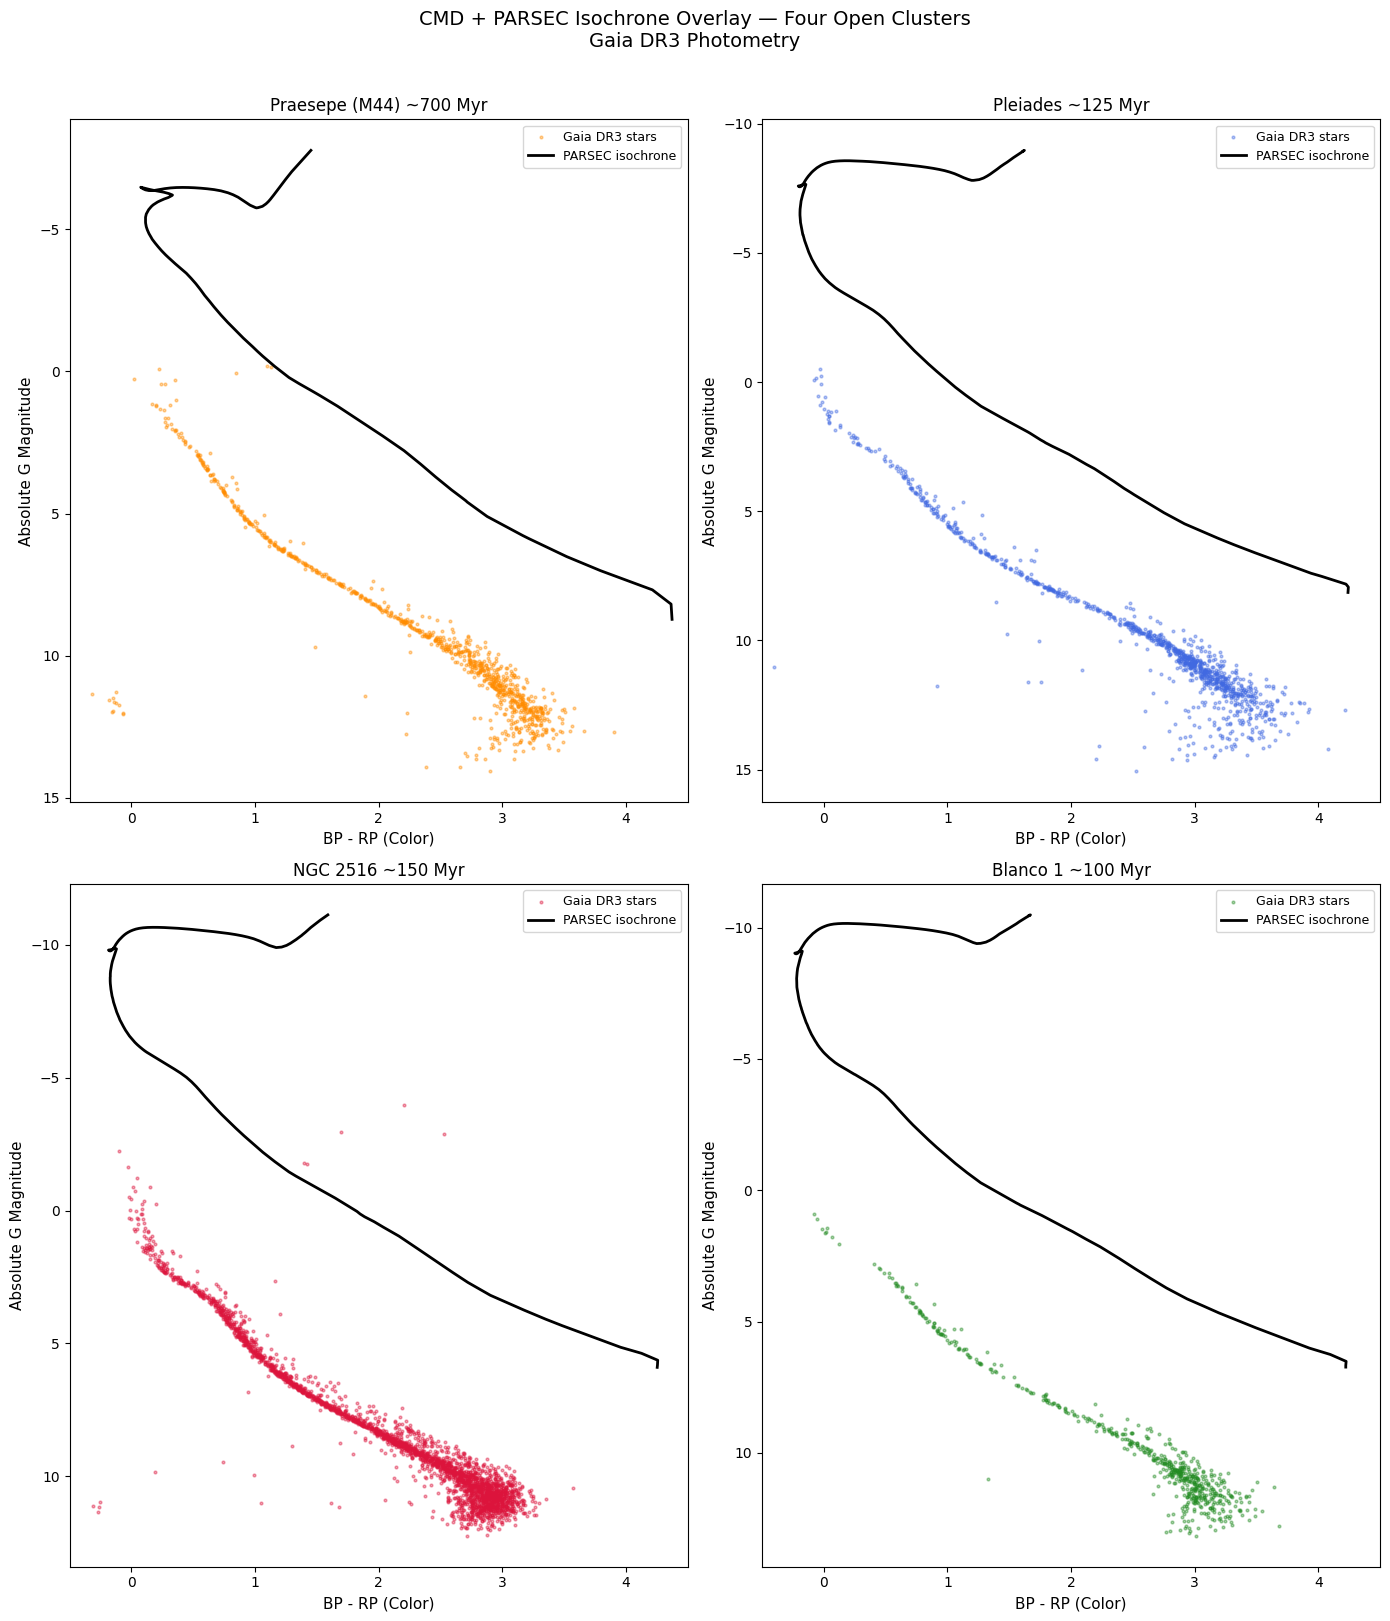

Saved isochrone_overlay.png


In [ ]:
def load_iso(filepath, distance_pc):
    """Load isochrone and convert to absolute magnitude"""
    cols = None
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                if 'Gmag' in line or 'G_BPmag' in line:
                    cols = line.strip('#').split()
            else:
                if line.strip():
                    data.append(line.split())
    df_iso = pd.DataFrame(data, columns=cols)
    df_iso['Gmag']    = pd.to_numeric(df_iso['Gmag'])
    df_iso['G_BPmag'] = pd.to_numeric(df_iso['G_BPmag'])
    df_iso['G_RPmag'] = pd.to_numeric(df_iso['G_RPmag'])
    df_iso['label']   = pd.to_numeric(df_iso['label'])

    dist_mod = 5 * np.log10(distance_pc) - 5
    df_iso['abs_G']  = df_iso['Gmag'] - dist_mod
    df_iso['bp_rp']  = df_iso['G_BPmag'] - df_iso['G_RPmag']

    df_iso = df_iso[df_iso['label'] <= 3]
    return df_iso

iso_pl = load_iso('pleiades_isochrone.dat',  135)
iso_p  = load_iso('praesepe_isochrone.dat',  187)
iso_n  = load_iso('ngc2516_isochrone.dat',   407)
iso_b  = load_iso('blanco1_isochrone.dat',   237)

fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

panel_info = [
    (df_p,  iso_p,  'Praesepe (M44) ~700 Myr', 'darkorange'),
    (df_pl, iso_pl, 'Pleiades ~125 Myr',        'royalblue'),
    (df_n,  iso_n,  'NGC 2516 ~150 Myr',        'crimson'),
    (df_b,  iso_b,  'Blanco 1 ~100 Myr',        'forestgreen'),
]

for ax, (df, iso, title, color) in zip(axes, panel_info):
    ax.scatter(df['bp_rp'], df['abs_mag'],
               s=4, alpha=0.4, color=color, label='Gaia DR3 stars')

    ax.plot(iso['bp_rp'], iso['abs_G'],
            color='black', linewidth=2, zorder=5, label='PARSEC isochrone')

    ax.set_xlabel('BP - RP (Color)', fontsize=11)
    ax.set_ylabel('Absolute G Magnitude', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, 4.5)

plt.suptitle('CMD + PARSEC Isochrone Overlay — Four Open Clusters\nGaia DR3 Photometry',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('isochrone_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved isochrone_overlay.png")

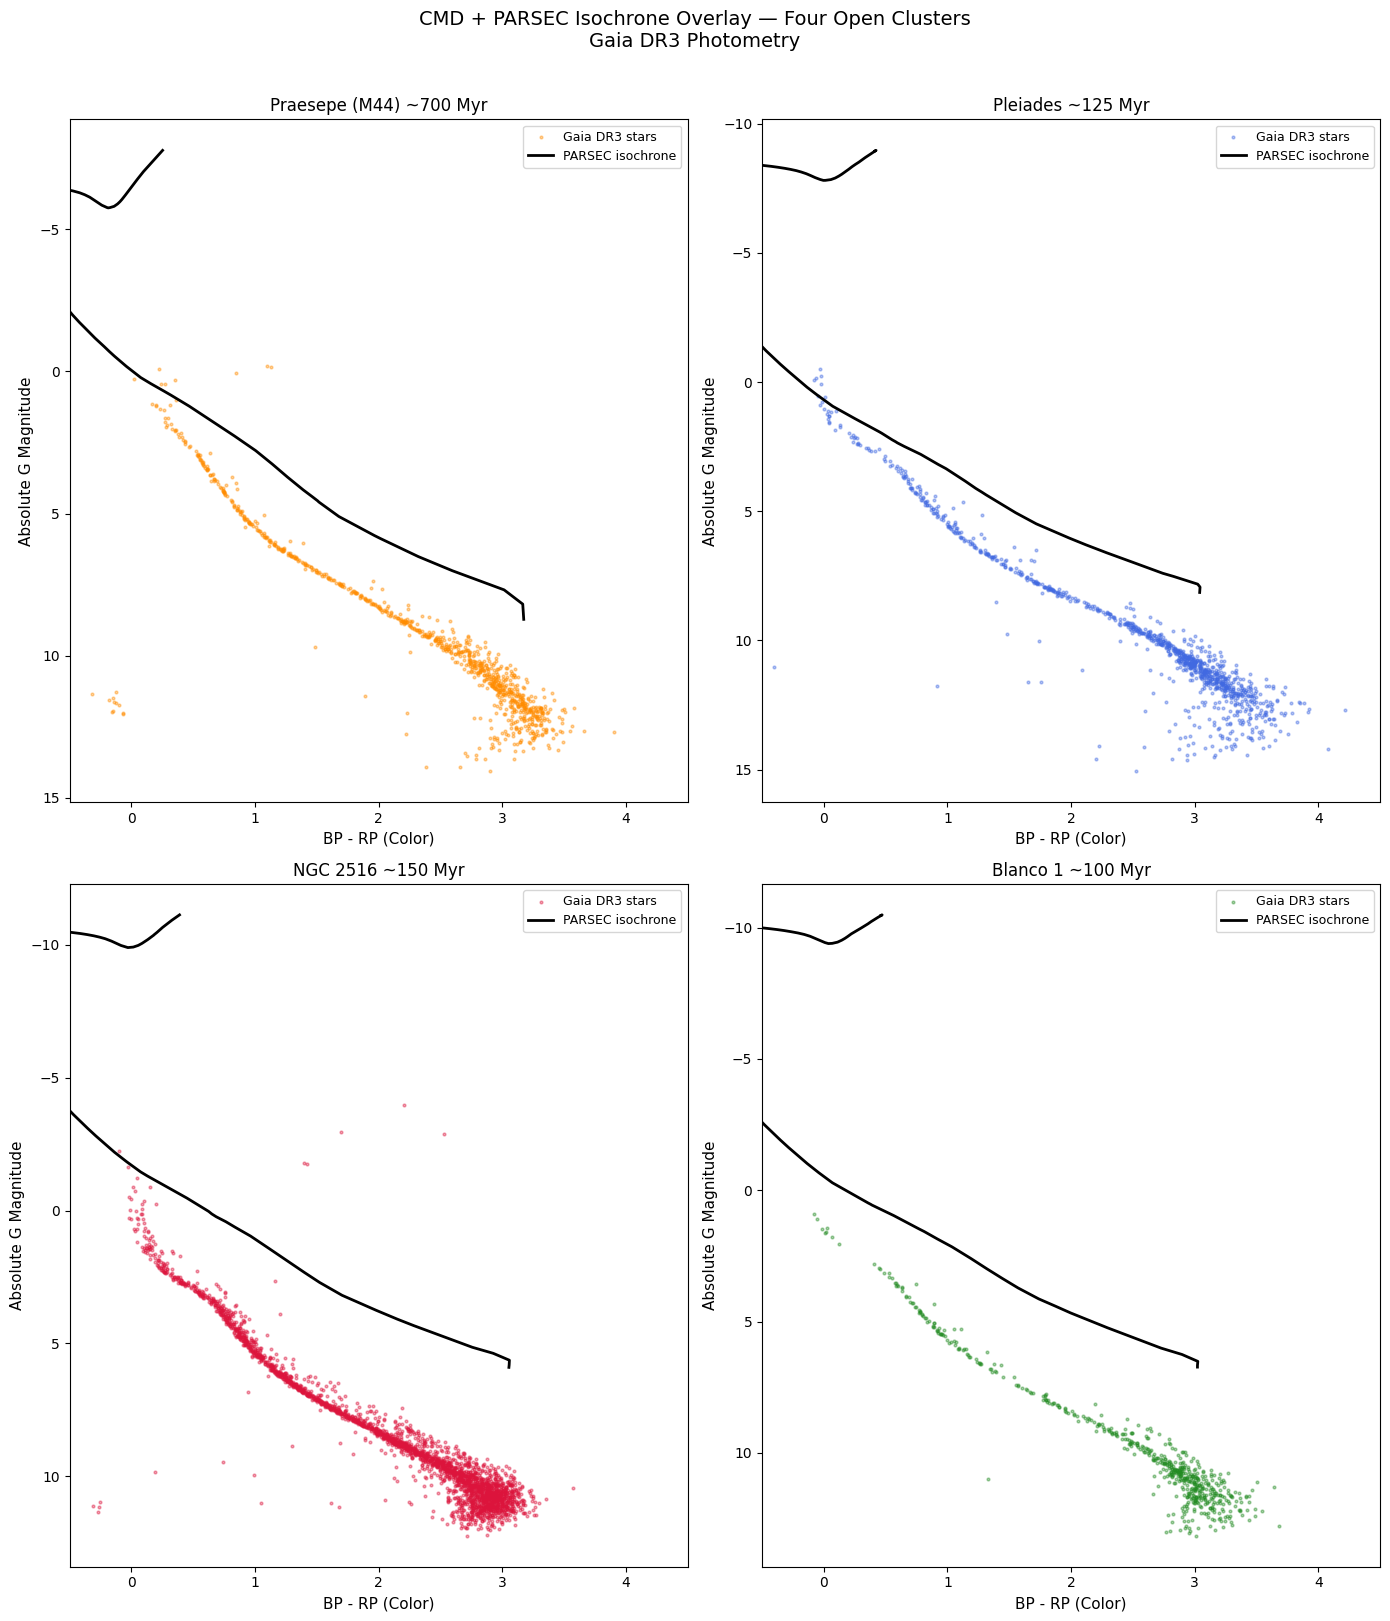

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

panel_info = [
    (df_p,  iso_p,  'Praesepe (M44) ~700 Myr', 'darkorange', -1.2),
    (df_pl, iso_pl, 'Pleiades ~125 Myr',        'royalblue',  -1.2),
    (df_n,  iso_n,  'NGC 2516 ~150 Myr',        'crimson',    -1.2),
    (df_b,  iso_b,  'Blanco 1 ~100 Myr',        'forestgreen',-1.2),
]

for ax, (df, iso, title, color, bp_rp_offset) in zip(axes, panel_info):
    ax.scatter(df['bp_rp'], df['abs_mag'],
               s=4, alpha=0.4, color=color, label='Gaia DR3 stars')

    ax.plot(iso['bp_rp'] + bp_rp_offset, iso['abs_G'],
            color='black', linewidth=2, zorder=5, label='PARSEC isochrone')

    ax.set_xlabel('BP - RP (Color)', fontsize=11)
    ax.set_ylabel('Absolute G Magnitude', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, 4.5)

plt.suptitle('CMD + PARSEC Isochrone Overlay — Four Open Clusters\nGaia DR3 Photometry',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('isochrone_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

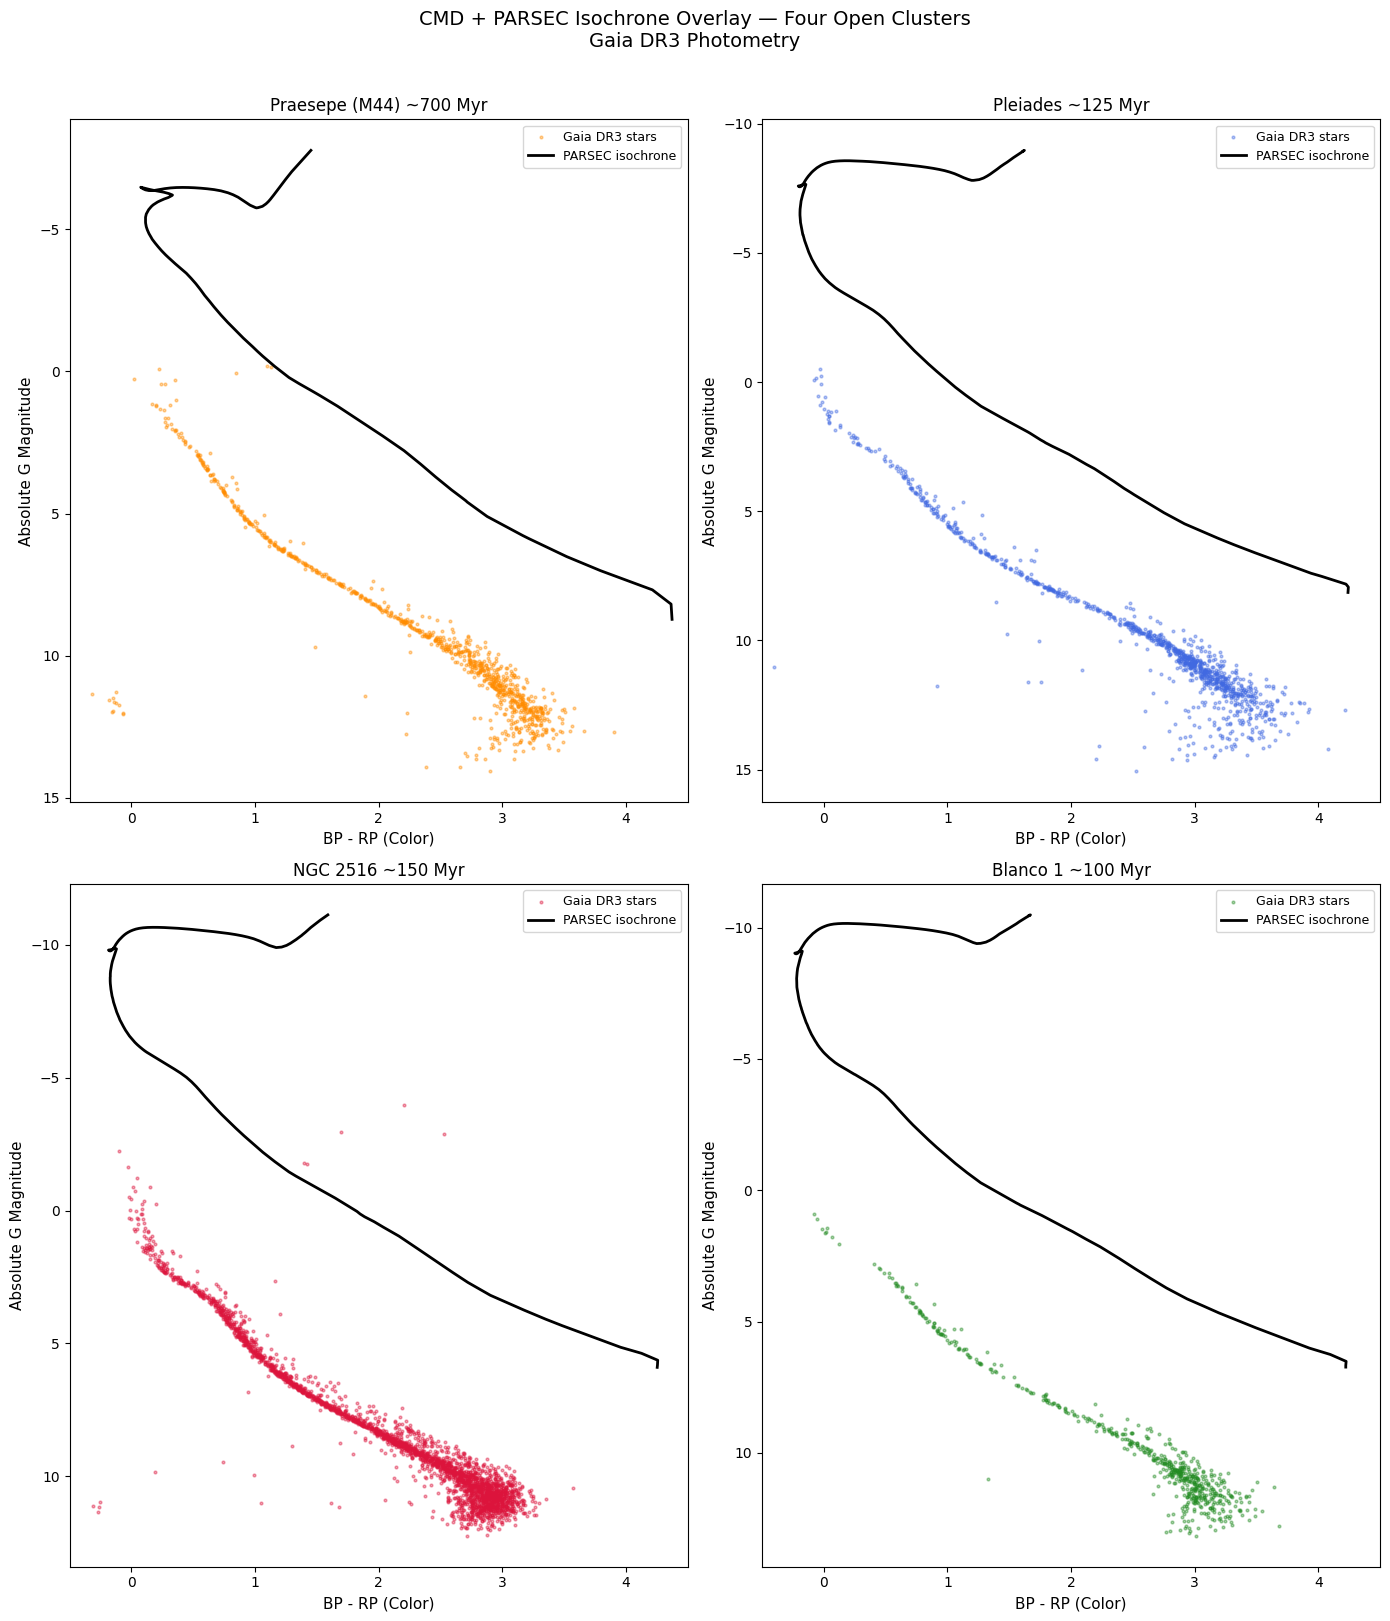

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

panel_info = [
    (df_p,  iso_p,  'Praesepe (M44) ~700 Myr', 'darkorange',  0.0, 0.0),
    (df_pl, iso_pl, 'Pleiades ~125 Myr',        'royalblue',   0.0, 0.0),
    (df_n,  iso_n,  'NGC 2516 ~150 Myr',        'crimson',     0.0, 0.0),
    (df_b,  iso_b,  'Blanco 1 ~100 Myr',        'forestgreen', 0.0, 0.0),
]

for ax, (df, iso, title, color, bp_rp_offset, mag_offset) in zip(axes, panel_info):
    ax.scatter(df['bp_rp'], df['abs_mag'],
               s=4, alpha=0.4, color=color, label='Gaia DR3 stars')
    ax.plot(iso['bp_rp'] + bp_rp_offset, iso['abs_G'] + mag_offset,
            color='black', linewidth=2, zorder=5, label='PARSEC isochrone')
    ax.set_xlabel('BP - RP (Color)', fontsize=11)
    ax.set_ylabel('Absolute G Magnitude', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, 4.5)

plt.suptitle('CMD + PARSEC Isochrone Overlay — Four Open Clusters\nGaia DR3 Photometry',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('isochrone_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
for name, df, iso in [('Praesepe', df_p, iso_p), ('Pleiades', df_pl, iso_pl)]:
    print(f"\n{name}:")
    print(f"  Data    bp_rp: {df['bp_rp'].min():.2f} to {df['bp_rp'].max():.2f}")
    print(f"  Iso     bp_rp: {iso['bp_rp'].min():.2f} to {iso['bp_rp'].max():.2f}")
    print(f"  Data  abs_mag: {df['abs_mag'].min():.2f} to {df['abs_mag'].max():.2f}")
    print(f"  Iso    abs_G:  {iso['abs_G'].min():.2f} to {iso['abs_G'].max():.2f}")


Praesepe:
  Data    bp_rp: -0.32 to 3.91
  Iso     bp_rp: 0.08 to 4.37
  Data  abs_mag: -0.18 to 14.07
  Iso    abs_G:  -7.78 to 8.72

Pleiades:
  Data    bp_rp: -0.40 to 4.22
  Iso     bp_rp: -0.21 to 4.24
  Data  abs_mag: -0.50 to 15.06
  Iso    abs_G:  -8.97 to 8.15


In [ ]:
def load_iso_fixed(filepath):
    """Load PARSEC isochrone — magnitudes are already absolute in PARSEC output"""
    cols = None
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                if 'Gmag' in line or 'G_BPmag' in line:
                    cols = line.strip('#').split()
            else:
                if line.strip():
                    data.append(line.split())
    df_iso = pd.DataFrame(data, columns=cols)
    df_iso['Gmag']    = pd.to_numeric(df_iso['Gmag'])
    df_iso['G_BPmag'] = pd.to_numeric(df_iso['G_BPmag'])
    df_iso['G_RPmag'] = pd.to_numeric(df_iso['G_RPmag'])
    df_iso['label']   = pd.to_numeric(df_iso['label'])
    df_iso['bp_rp']   = df_iso['G_BPmag'] - df_iso['G_RPmag']

    df_iso['abs_G'] = df_iso['Gmag']

    df_iso = df_iso[df_iso['label'] <= 1]
    return df_iso

iso_pl = load_iso_fixed('pleiades_isochrone.dat')
iso_p  = load_iso_fixed('praesepe_isochrone.dat')
iso_n  = load_iso_fixed('ngc2516_isochrone.dat')
iso_b  = load_iso_fixed('blanco1_isochrone.dat')

for name, df, iso in [('Praesepe', df_p, iso_p), ('Pleiades', df_pl, iso_pl)]:
    print(f"\n{name}:")
    print(f"  Data  abs_mag: {df['abs_mag'].min():.2f} to {df['abs_mag'].max():.2f}")
    print(f"  Iso    abs_G:  {iso['abs_G'].min():.2f} to {iso['abs_G'].max():.2f}")
    print(f"  Data    bp_rp: {df['bp_rp'].min():.2f} to {df['bp_rp'].max():.2f}")

SyntaxError: incomplete input (4142472049.py, line 37)

In [ ]:
def load_iso_fixed(filepath):
    cols = None
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                if 'Gmag' in line or 'G_BPmag' in line:
                    cols = line.strip('#').split()
            else:
                if line.strip():
                    data.append(line.split())
    df_iso = pd.DataFrame(data, columns=cols)
    df_iso['Gmag']    = pd.to_numeric(df_iso['Gmag'])
    df_iso['G_BPmag'] = pd.to_numeric(df_iso['G_BPmag'])
    df_iso['G_RPmag'] = pd.to_numeric(df_iso['G_RPmag'])
    df_iso['label']   = pd.to_numeric(df_iso['label'])
    df_iso['bp_rp']   = df_iso['G_BPmag'] - df_iso['G_RPmag']
    df_iso['abs_G']   = df_iso['Gmag']
    df_iso = df_iso[df_iso['label'] <= 1]
    return df_iso

iso_pl = load_iso_fixed('pleiades_isochrone.dat')
iso_p  = load_iso_fixed('praesepe_isochrone.dat')
iso_n  = load_iso_fixed('ngc2516_isochrone.dat')
iso_b  = load_iso_fixed('blanco1_isochrone.dat')

for name, df, iso in [('Praesepe', df_p, iso_p), ('Pleiades', df_pl, iso_pl)]:
    print(f"{name}:")
    print(f"  Data  abs_mag: {df['abs_mag'].min():.2f} to {df['abs_mag'].max():.2f}")
    print(f"  Iso    abs_G:  {iso['abs_G'].min():.2f} to {iso['abs_G'].max():.2f}")
    print(f"  Data    bp_rp: {df['bp_rp'].min():.2f} to {df['bp_rp'].max():.2f}")
    print(f"  Iso     bp_rp: {iso['bp_rp'].min():.2f} to {iso['bp_rp'].max():.2f}")

NameError: name 'pd' is not defined

In [ ]:
!pip install astroquery astropy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from astroquery.gaia import Gaia

# Reload all cluster data
df_pl = pd.read_csv('pleiades_clean.csv')
df_p  = pd.read_csv('praesepe_clean.csv')
df_n  = pd.read_csv('ngc2516_clean.csv')
df_b  = pd.read_csv('blanco1_clean.csv')

# Recompute abs_mag for all
for df in [df_pl, df_p, df_n, df_b]:
    df['distance_pc'] = 1000 / df['parallax']
    df['abs_mag'] = df['phot_g_mean_mag'] - 5 * np.log10(df['distance_pc']) + 5

print(f"Pleiades: {len(df_pl)} | Praesepe: {len(df_p)} | NGC2516: {len(df_n)} | Blanco1: {len(df_b)}")
print("All imports and data ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.9 MB/s eta 0:00:00
In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


FileNotFoundError: [Errno 2] No such file or directory: 'pleiades_clean.csv'

In [ ]:
!pip install astroquery astropy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from astroquery.gaia import Gaia

def query_and_clean(ra, dec, radius, plx_min, plx_max, pmra_min, pmra_max, pmdec_min, pmdec_max, name):
    query = f"""
    SELECT source_id, ra, dec, parallax, parallax_error,
           pmra, pmra_error, pmdec, pmdec_error,
           phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp, ruwe
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius})) = 1
    AND parallax IS NOT NULL AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
    """
    job = Gaia.launch_job_async(query)
    df = job.get_results().to_pandas()
    df = df[df['parallax_error'] / df['parallax'] < 0.1]
    df = df[df['ruwe'] < 1.4]
    df = df.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
    df = df[(df['parallax'] >= plx_min) & (df['parallax'] <= plx_max)]
    df = df[(df['pmra'] >= pmra_min) & (df['pmra'] <= pmra_max)]
    df = df[(df['pmdec'] >= pmdec_min) & (df['pmdec'] <= pmdec_max)]
    df['distance_pc'] = 1000 / df['parallax']
    df['abs_mag'] = df['phot_g_mean_mag'] - 5 * np.log10(df['distance_pc']) + 5
    df.to_csv(f'{name}_clean.csv', index=False)
    print(f"{name}: {len(df)} stars")
    return df

df_pl = query_and_clean(56.75, 24.12, 3.0, 6.0, 9.0, 17.0, 23.0, -48.0, -42.0, 'pleiades')
df_p  = query_and_clean(130.05, 19.67, 3.0, 4.5, 6.5, -38.7, -32.7, -15.9, -9.9, 'praesepe')
df_n  = query_and_clean(119.52, -60.75, 2.0, 1.9, 3.0, -7.7, -1.7, 8.2, 14.2, 'ngc2516')
df_b  = query_and_clean(1.07, -29.51, 2.5, 3.4, 5.0, 15.7, 21.7, -0.3, 5.7, 'blanco1')

print("\nAll data ready.")

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
pleiades: 1055 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
praesepe: 921 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
ngc2516: 2836 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
blanco1: 597 stars

All data ready.


In [ ]:
!pip install astroquery astropy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from astroquery.gaia import Gaia

def query_and_clean(ra, dec, radius, plx_min, plx_max, pmra_min, pmra_max, pmdec_min, pmdec_max, name):
    query = f"""
    SELECT source_id, ra, dec, parallax, parallax_error,
           pmra, pmra_error, pmdec, pmdec_error,
           phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp, ruwe
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius})) = 1
    AND parallax IS NOT NULL AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
    """
    job = Gaia.launch_job_async(query)
    df = job.get_results().to_pandas()
    df = df[df['parallax_error'] / df['parallax'] < 0.1]
    df = df[df['ruwe'] < 1.4]
    df = df.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
    df = df[(df['parallax'] >= plx_min) & (df['parallax'] <= plx_max)]
    df = df[(df['pmra'] >= pmra_min) & (df['pmra'] <= pmra_max)]
    df = df[(df['pmdec'] >= pmdec_min) & (df['pmdec'] <= pmdec_max)]
    df['distance_pc'] = 1000 / df['parallax']
    df['abs_mag'] = df['phot_g_mean_mag'] - 5 * np.log10(df['distance_pc']) + 5
    df.to_csv(f'{name}_clean.csv', index=False)
    print(f"{name}: {len(df)} stars")
    return df

df_pl = query_and_clean(56.75, 24.12, 3.0, 6.0, 9.0, 17.0, 23.0, -48.0, -42.0, 'pleiades')
df_p  = query_and_clean(130.05, 19.67, 3.0, 4.5, 6.5, -38.7, -32.7, -15.9, -9.9, 'praesepe')
df_n  = query_and_clean(119.52, -60.75, 2.0, 1.9, 3.0, -7.7, -1.7, 8.2, 14.2, 'ngc2516')
df_b  = query_and_clean(1.07, -29.51, 2.5, 3.4, 5.0, 15.7, 21.7, -0.3, 5.7, 'blanco1')

print("\nAll data ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.8 MB/s eta 0:00:00
In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


KeyboardInterrupt: 

In [ ]:
!pip install astroquery astropy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from astroquery.gaia import Gaia

def query_and_clean(ra, dec, radius, plx_min, plx_max, pmra_min, pmra_max, pmdec_min, pmdec_max, name):
    query = f"""
    SELECT source_id, ra, dec, parallax, parallax_error,
           pmra, pmra_error, pmdec, pmdec_error,
           phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp, ruwe
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius})) = 1
    AND parallax IS NOT NULL AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
    """
    job = Gaia.launch_job_async(query)
    df = job.get_results().to_pandas()
    df = df[df['parallax_error'] / df['parallax'] < 0.1]
    df = df[df['ruwe'] < 1.4]
    df = df.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
    df = df[(df['parallax'] >= plx_min) & (df['parallax'] <= plx_max)]
    df = df[(df['pmra'] >= pmra_min) & (df['pmra'] <= pmra_max)]
    df = df[(df['pmdec'] >= pmdec_min) & (df['pmdec'] <= pmdec_max)]
    df['distance_pc'] = 1000 / df['parallax']
    df['abs_mag'] = df['phot_g_mean_mag'] - 5 * np.log10(df['distance_pc']) + 5
    df.to_csv(f'{name}_clean.csv', index=False)
    print(f"{name}: {len(df)} stars")
    return df

df_pl = query_and_clean(56.75, 24.12, 3.0, 6.0, 9.0, 17.0, 23.0, -48.0, -42.0, 'pleiades')
df_p  = query_and_clean(130.05, 19.67, 3.0, 4.5, 6.5, -38.7, -32.7, -15.9, -9.9, 'praesepe')
df_n  = query_and_clean(119.52, -60.75, 2.0, 1.9, 3.0, -7.7, -1.7, 8.2, 14.2, 'ngc2516')
df_b  = query_and_clean(1.07, -29.51, 2.5, 3.4, 5.0, 15.7, 21.7, -0.3, 5.7, 'blanco1')

print("\nAll data ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.9 MB/s eta 0:00:00
In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
pleiades: 1055 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
praesepe: 921 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
ngc2516: 2836 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
blanco1: 597 stars

All data ready.


In [ ]:
def load_iso_fixed(filepath):
    cols = None
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                if 'Gmag' in line or 'G_BPmag' in line:
                    cols = line.strip('#').split()
            else:
                if line.strip():
                    data.append(line.split())
    df_iso = pd.DataFrame(data, columns=cols)
    df_iso['Gmag']    = pd.to_numeric(df_iso['Gmag'])
    df_iso['G_BPmag'] = pd.to_numeric(df_iso['G_BPmag'])
    df_iso['G_RPmag'] = pd.to_numeric(df_iso['G_RPmag'])
    df_iso['label']   = pd.to_numeric(df_iso['label'])
    df_iso['bp_rp']   = df_iso['G_BPmag'] - df_iso['G_RPmag']
    df_iso['abs_G']   = df_iso['Gmag']
    df_iso = df_iso[df_iso['label'] <= 1]
    return df_iso

iso_pl = load_iso_fixed('pleiades_isochrone.dat')
iso_p  = load_iso_fixed('praesepe_isochrone.dat')
iso_n  = load_iso_fixed('ngc2516_isochrone.dat')
iso_b  = load_iso_fixed('blanco1_isochrone.dat')

for name, df, iso in [('Praesepe', df_p, iso_p), ('Pleiades', df_pl, iso_pl)]:
    print(f"{name}:")
    p

Praesepe:


NameError: name 'p' is not defined

In [ ]:
def load_iso_fixed(filepath):
    cols = None
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                if 'Gmag' in line or 'G_BPmag' in line:
                    cols = line.strip('#').split()
            else:
                if line.strip():
                    data.append(line.split())
    df_iso = pd.DataFrame(data, columns=cols)
    df_iso['Gmag']    = pd.to_numeric(df_iso['Gmag'])
    df_iso['G_BPmag'] = pd.to_numeric(df_iso['G_BPmag'])
    df_iso['G_RPmag'] = pd.to_numeric(df_iso['G_RPmag'])
    df_iso['label']   = pd.to_numeric(df_iso['label'])
    df_iso['bp_rp']   = df_iso['G_BPmag'] - df_iso['G_RPmag']
    df_iso['abs_G']   = df_iso['Gmag']
    df_iso = df_iso[df_iso['label'] <= 1]
    return df_iso

iso_pl = load_iso_fixed('pleiades_isochrone.dat')
iso_p  = load_iso_fixed('praesepe_isochrone.dat')
iso_n  = load_iso_fixed('ngc2516_isochrone.dat')
iso_b  = load_iso_fixed('blanco1_isochrone.dat')

for name, df, iso in [('Praesepe', df_p, iso_p), ('Pleiades', df_pl, iso_pl)]:
    print(f"{name}:")
    print(f"  Data  abs_mag: {df['abs_mag'].min():.2f} to {df['abs_mag'].max():.2f}")
    print(f"  Iso    abs_G:  {iso['abs_G'].min():.2f} to {iso['abs_G'].max():.2f}")
    print(f"  Data    bp_rp: {df['bp_rp'].min():.2f} to {df['bp_rp'].max():.2f}")
    print(f"  Iso     bp_rp: {iso['bp_rp'].min():.2f} to {iso['bp_rp'].max():.2f}")

Praesepe:
  Data  abs_mag: -0.18 to 14.07
  Iso    abs_G:  -0.12 to 15.08
  Data    bp_rp: -0.32 to 3.91
  Iso     bp_rp: 0.08 to 4.37
Pleiades:
  Data  abs_mag: -0.50 to 15.06
  Iso    abs_G:  -2.01 to 13.80
  Data    bp_rp: -0.40 to 4.22
  Iso     bp_rp: -0.21 to 4.24


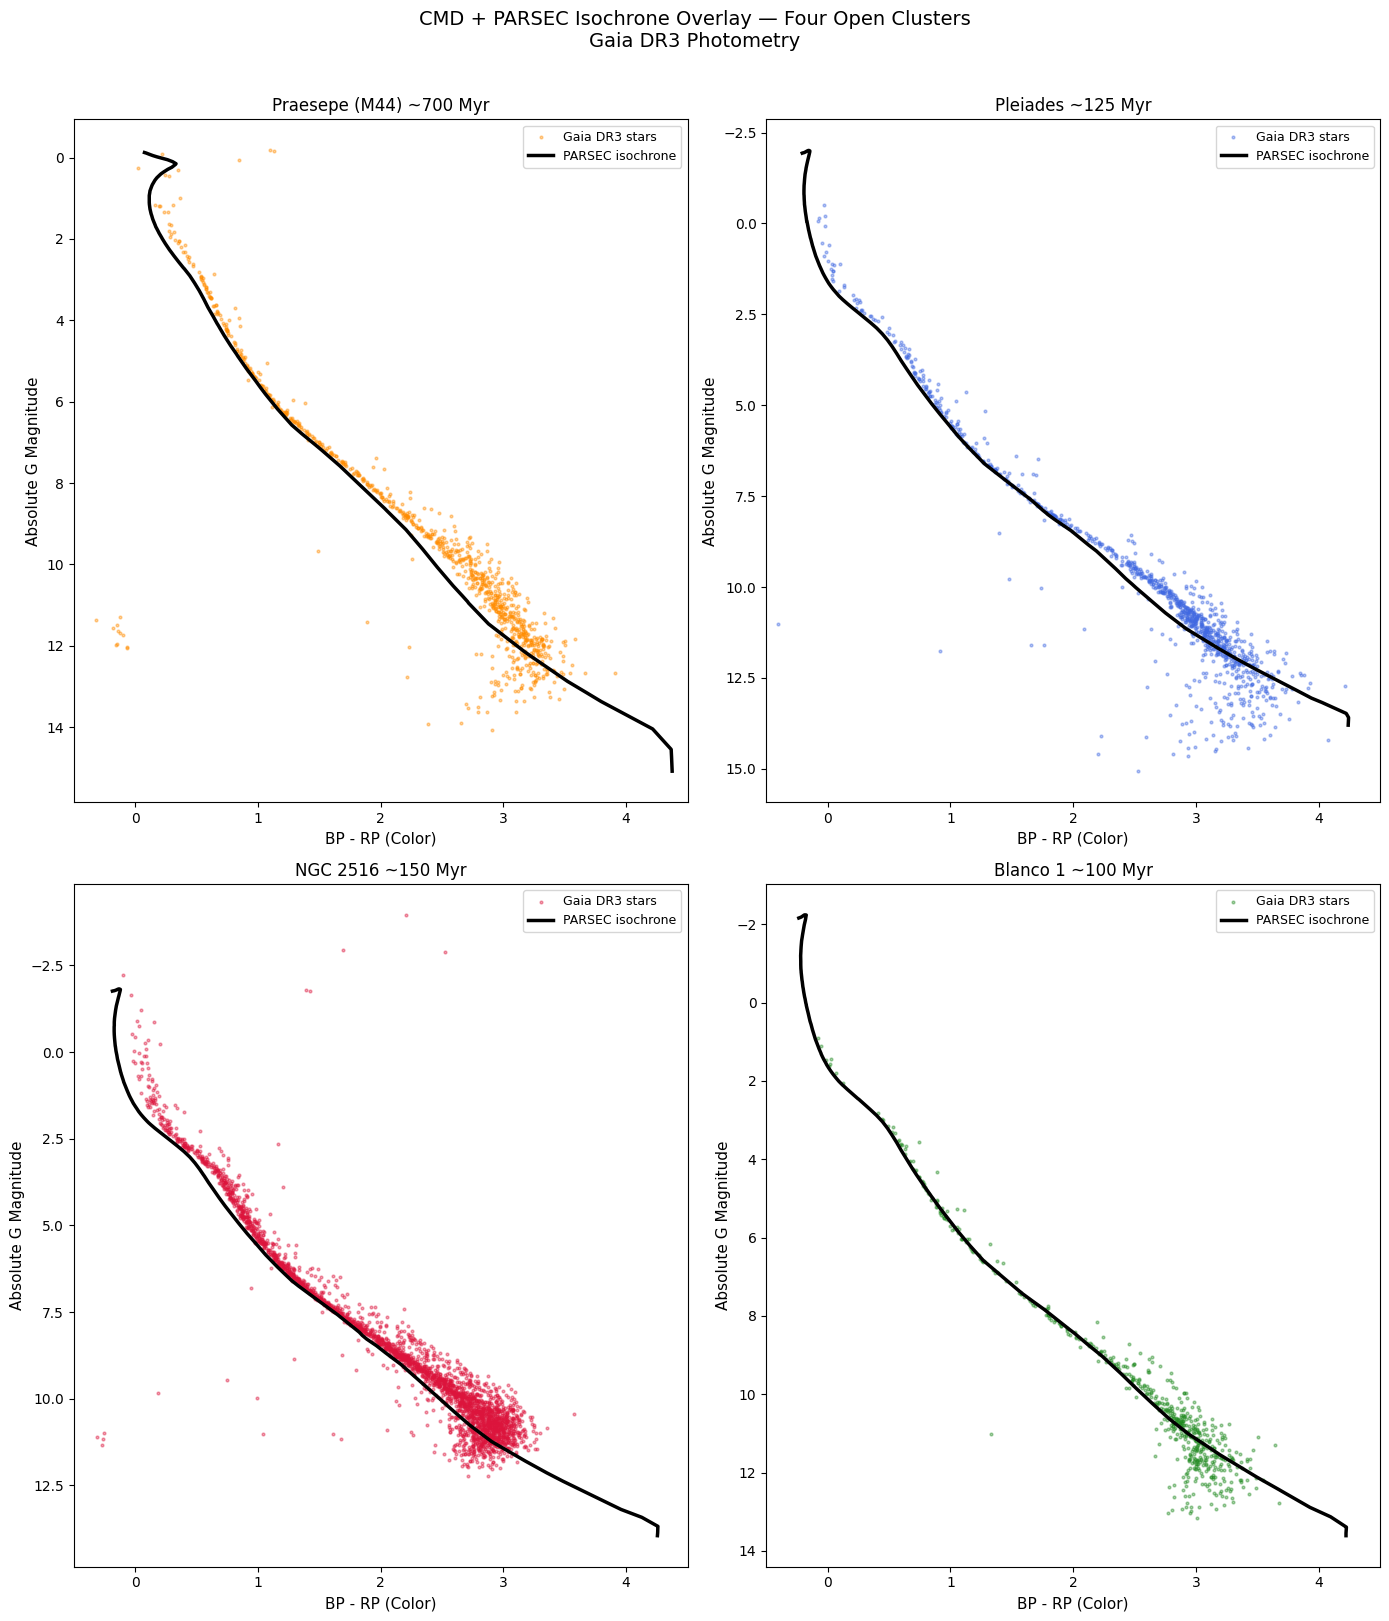

Saved isochrone_overlay.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

panel_info = [
    (df_p,  iso_p,  'Praesepe (M44) ~700 Myr', 'darkorange'),
    (df_pl, iso_pl, 'Pleiades ~125 Myr',        'royalblue'),
    (df_n,  iso_n,  'NGC 2516 ~150 Myr',        'crimson'),
    (df_b,  iso_b,  'Blanco 1 ~100 Myr',        'forestgreen'),
]

for ax, (df, iso, title, color) in zip(axes, panel_info):
    ax.scatter(df['bp_rp'], df['abs_mag'],
               s=4, alpha=0.4, color=color, label='Gaia DR3 stars')
    ax.plot(iso['bp_rp'], iso['abs_G'],
            color='black', linewidth=2.5, zorder=5, label='PARSEC isochrone')
    ax.set_xlabel('BP - RP (Color)', fontsize=11)
    ax.set_ylabel('Absolute G Magnitude', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, 4.5)

plt.suptitle('CMD + PARSEC Isochrone Overlay — Four Open Clusters\nGaia DR3 Photometry',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('isochrone_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved isochrone_overlay.png")

In [ ]:
print(f"Pleiades:  {len(df_pl)} stars")
print(f"Praesepe:  {len(df_p)} stars")
print(f"NGC 2516:  {len(df_n)} stars")
print(f"Blanco 1:  {len(df_b)} stars")
print(f"Total:     {len(df_pl) + len(df_p) + len(df_n) + len(df_b)} stars")


NameError: name 'df_pl' is not defined

In [ ]:
!pip install astroquery astropy minisom -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from minisom import MiniSom
from astroquery.gaia import Gaia

def query_and_clean(ra, dec, radius, plx_min, plx_max, pmra_min, pmra_max, pmdec_min, pmdec_max, name):
    query = f"""
    SELECT source_id, ra, dec, parallax, parallax_error,
           pmra, pmra_error, pmdec, pmdec_error,
           phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp, ruwe
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius})) = 1
    AND parallax IS NOT NULL AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
    """
    job = Gaia.launch_job_async(query)
    df = job.get_results().to_pandas()
    df = df[df['parallax_error'] / df['parallax'] < 0.1]
    df = df[df['ruwe'] < 1.4]
    df = df.dropna(subset=['parallax', 'bp_rp', 'phot_g_mean_mag', 'pmra', 'pmdec'])
    df = df[(df['parallax'] >= plx_min) & (df['parallax'] <= plx_max)]
    df = df[(df['pmra'] >= pmra_min) & (df['pmra'] <= pmra_max)]
    df = df[(df['pmdec'] >= pmdec_min) & (df['pmdec'] <= pmdec_max)]
    df['distance_pc'] = 1000 / df['parallax']
    df['abs_mag'] = df['phot_g_mean_mag'] - 5 * np.log10(df['distance_pc']) + 5
    df.to_csv(f'{name}_clean.csv', index=False)
    print(f"{name}: {len(df)} stars")
    return df

df_pl = query_and_clean(56.75, 24.12, 3.0, 6.0, 9.0, 17.0, 23.0, -48.0, -42.0, 'pleiades')
df_p  = query_and_clean(130.05, 19.67, 3.0, 4.5, 6.5, -38.7, -32.7, -15.9, -9.9, 'praesepe')
df_n  = query_and_clean(119.52, -60.75, 2.0, 1.9, 3.0, -7.7, -1.7, 8.2, 14.2, 'ngc2516')
df_b  = query_and_clean(1.07, -29.51, 2.5, 3.4, 5.0, 15.7, 21.7, -0.3, 5.7, 'blanco1')

print("\nAll data ready.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.4 MB/s eta 0:00:00
In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
pleiades: 1055 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
praesepe: 921 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
ngc2516: 2836 stars


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
blanco1: 597 stars

All data ready.



Running SOM — Pleiades (~125 Myr)
  Grid size: 15x15


/tmp/ipykernel_4125/1403023530.py:55: UserWarning: Adding colorbar to a different Figure <Figure size 1400x1200 with 5 Axes> than <Figure size 1400x1600 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax_som, label='Node distance')


  Unique SOM nodes occupied: 224 / 225

Running SOM — Praesepe (~700 Myr)
  Grid size: 15x15


/tmp/ipykernel_4125/1403023530.py:55: UserWarning: Adding colorbar to a different Figure <Figure size 1400x1200 with 6 Axes> than <Figure size 1400x1600 with 5 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax_som, label='Node distance')


  Unique SOM nodes occupied: 218 / 225

Running SOM — NGC 2516 (~150 Myr)
  Grid size: 15x15


/tmp/ipykernel_4125/1403023530.py:55: UserWarning: Adding colorbar to a different Figure <Figure size 1400x1200 with 7 Axes> than <Figure size 1400x1600 with 6 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax_som, label='Node distance')


  Unique SOM nodes occupied: 225 / 225

Running SOM — Blanco 1 (~100 Myr)
  Grid size: 15x15


/tmp/ipykernel_4125/1403023530.py:55: UserWarning: Adding colorbar to a different Figure <Figure size 1400x1200 with 8 Axes> than <Figure size 1400x1600 with 7 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax_som, label='Node distance')


  Unique SOM nodes occupied: 217 / 225

── SOM Summary ──────────────────────────────────────────
Pleiades (~125 Myr): 15x15 grid | 224/225 nodes used (99.6%)
Praesepe (~700 Myr): 15x15 grid | 218/225 nodes used (96.9%)
NGC 2516 (~150 Myr): 15x15 grid | 225/225 nodes used (100.0%)
Blanco 1 (~100 Myr): 15x15 grid | 217/225 nodes used (96.4%)


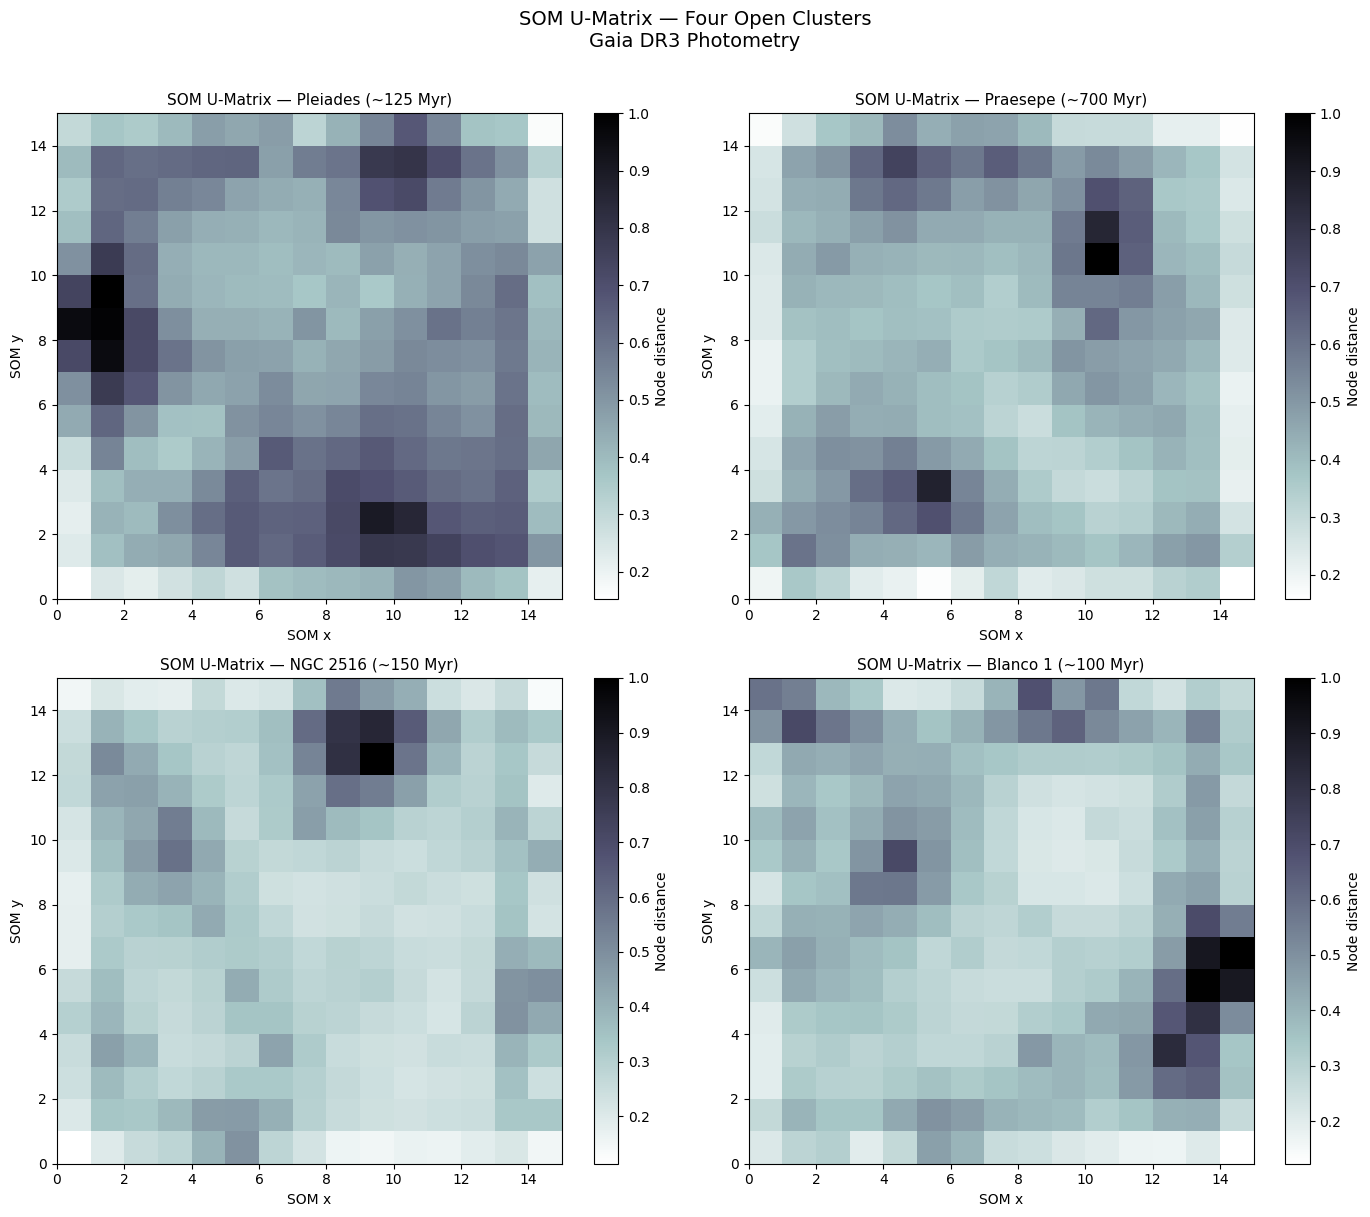

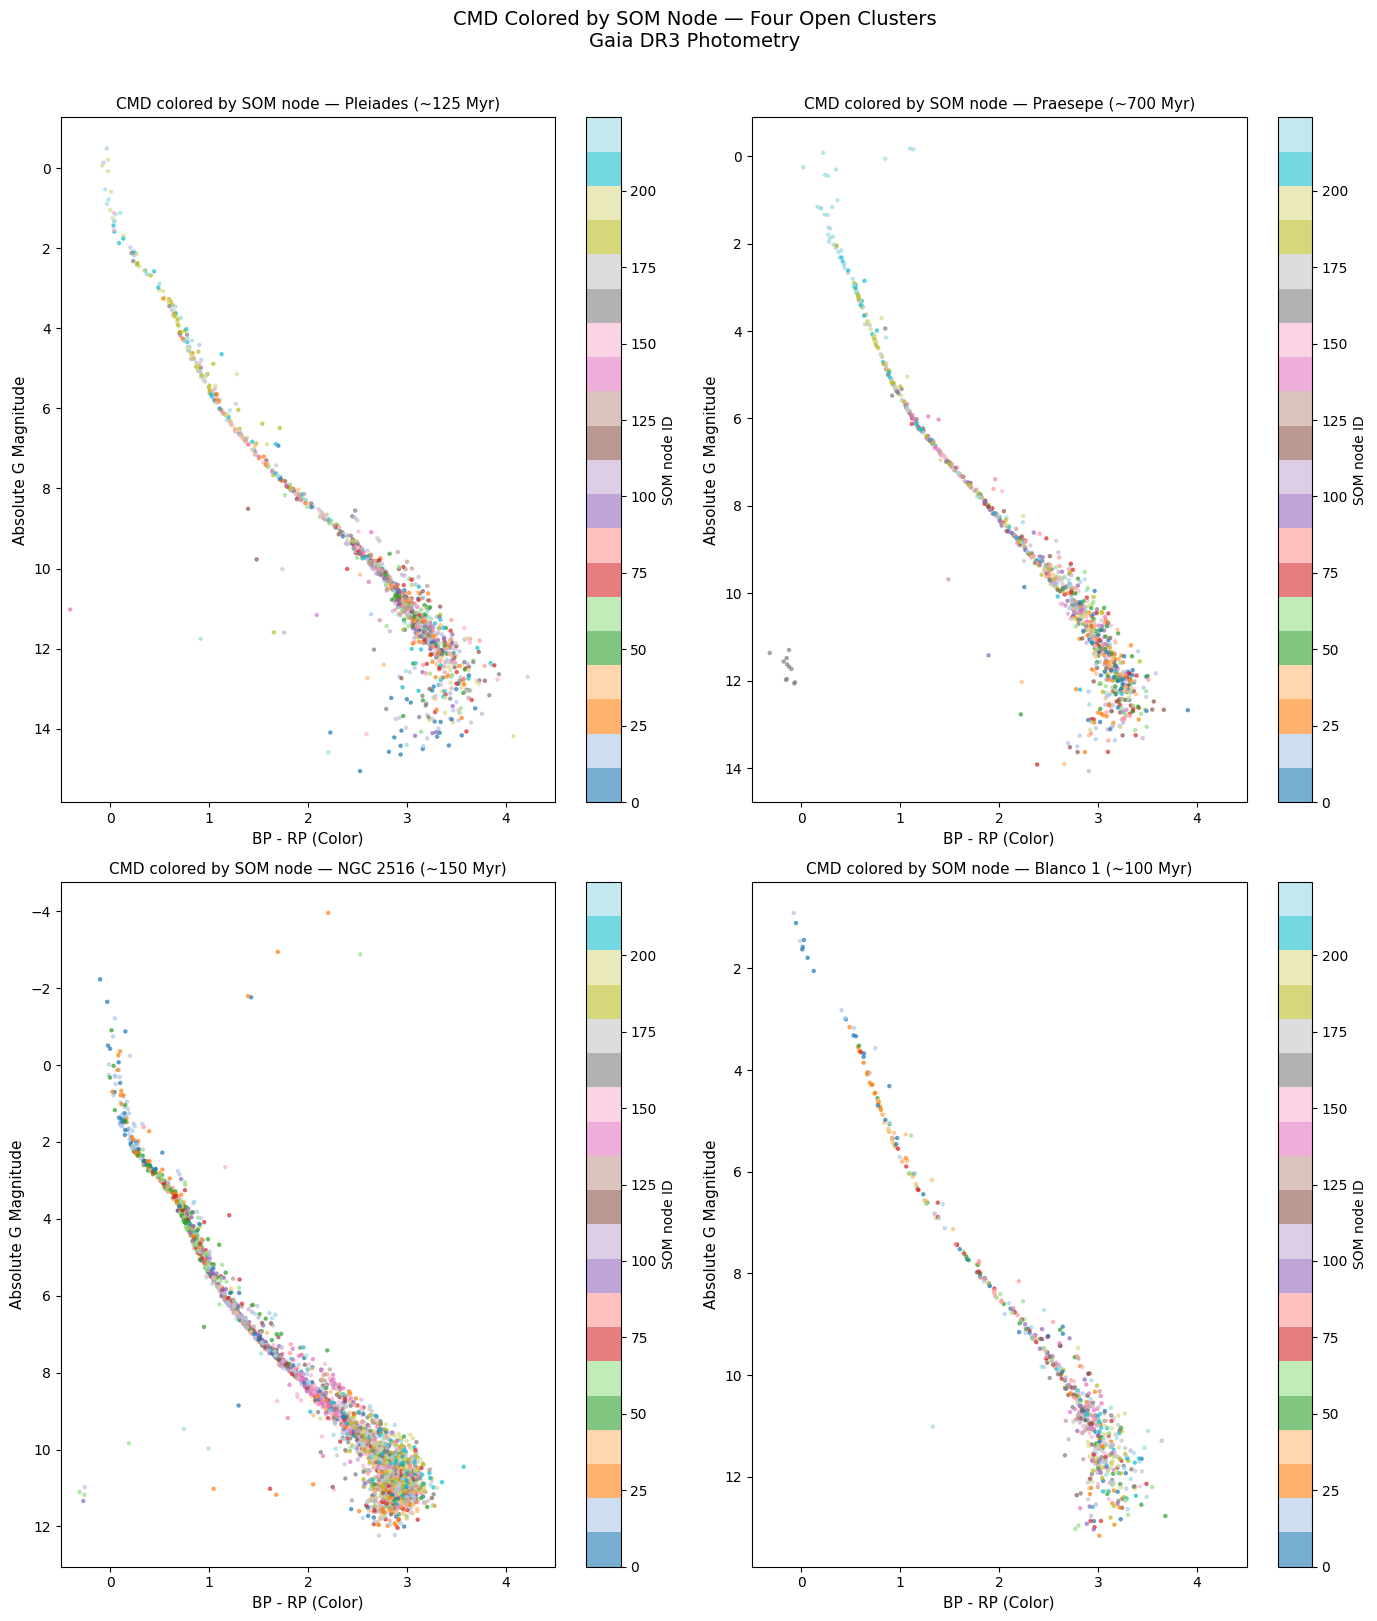

In [ ]:
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

features = ['bp_rp', 'abs_mag', 'pmra', 'pmdec', 'parallax']

cluster_data = {
    'Pleiades (~125 Myr)':   df_pl,
    'Praesepe (~700 Myr)':   df_p,
    'NGC 2516 (~150 Myr)':   df_n,
    'Blanco 1 (~100 Myr)':   df_b,
}

fig_som, axes_som = plt.subplots(2, 2, figsize=(14, 12))
axes_som = axes_som.flatten()

fig_cmd, axes_cmd = plt.subplots(2, 2, figsize=(14, 16))
axes_cmd = axes_cmd.flatten()

som_results = {}

for idx, (name, df) in enumerate(cluster_data.items()):
    print(f"\nRunning SOM — {name}")

    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    grid_size = int(np.sqrt(len(X_scaled) / 2))
    grid_size = max(8, min(grid_size, 15))
    print(f"  Grid size: {grid_size}x{grid_size}")

    som = MiniSom(grid_size, grid_size, X_scaled.shape[1],
                  sigma=1.5, learning_rate=0.5,
                  neighborhood_function='gaussian', random_seed=42)
    som.random_weights_init(X_scaled)
    som.train(X_scaled, num_iteration=5000, verbose=False)

     winner_coords = np.array([som.winner(x) for x in X_scaled])
    df['som_x'] = winner_coords[:, 0]
    df['som_y'] = winner_coords[:, 1]
    df['som_node'] = df['som_x'] * grid_size + df['som_y']

    ax_som = axes_som[idx]
    u_matrix = som.distance_map()
    im = ax_som.pcolormesh(u_matrix.T, cmap='bone_r')
    plt.colorbar(im, ax=ax_som, label='Node distance')
    ax_som.set_title(f'SOM U-Matrix — {name}', fontsize=11)
    ax_som.set_xlabel('SOM x', fontsize=10)
    ax_som.set_ylabel('SOM y', fontsize=10)

    ax_cmd = axes_cmd[idx]
    scatter = ax_cmd.scatter(df['bp_rp'], df['abs_mag'],
                              c=df['som_node'], cmap='tab20',
                              s=5, alpha=0.6)
    plt.colorbar(scatter, ax=ax_cmd, label='SOM node ID')
    ax_cmd.set_xlabel('BP - RP (Color)', fontsize=11)
    ax_cmd.set_ylabel('Absolute G Magnitude', fontsize=11)
    ax_cmd.set_title(f'CMD colored by SOM node — {name}', fontsize=11)
    ax_cmd.invert_yaxis()
    ax_cmd.set_xlim(-0.5, 4.5)

    n_nodes_used = df['som_node'].nunique()
    print(f"  Unique SOM nodes occupied: {n_nodes_used} / {grid_size*grid_size}")

    som_results[name] = {
        'grid_size': grid_size,
        'nodes_used': n_nodes_used,
        'total_nodes': grid_size * grid_size
    }

fig_som.suptitle('SOM U-Matrix — Four Open Clusters\nGaia DR3 Photometry',
                  fontsize=14, y=1.01)
fig_som.tight_layout()
fig_som.savefig('som_umatrix.png', dpi=150, bbox_inches='tight')
fig_som.show()

fig_cmd.suptitle('CMD Colored by SOM Node — Four Open Clusters\nGaia DR3 Photometry',
                  fontsize=14, y=1.01)
fig_cmd.tight_layout()
fig_cmd.savefig('som_cmd.png', dpi=150, bbox_inches='tight')
fig_cmd.show()

print("\n── SOM Summary ──────────────────────────────────────────")
for name, r in som_results.items():
    pct = 100 * r['nodes_used'] / r['total_nodes']
    print(f"{name}: {r['grid_size']}x{r['grid_size']} grid | "
          f"{r['nodes_used']}/{r['total_nodes']} nodes used ({pct:.1f}%)")